# 02 · 时间序列数据处理与可视化：场景化代码模板

这份 notebook 面向有限时间内的探索性研究：先确认数据的含义、质量和时间，再选择能回答具体问题的图。包含 **12 个数据处理模板 + 18 个可视化模板**，每个模板都有实际输出、中文注释、适用情形与容易误判的地方。

**使用方法：** A 部分数据处理先运行下面的 setup，再选择 D 模板。**只想画图，直接跳到 [B 部分](#visualization)**：每个 V 案例先展示输入表，再给具体任务和短代码；只需 B 部分的 import 和自己的 `df`。V 案例互不依赖，也不读取 A 部分的大型合成面板。所有示例数据均为教学构造，并非真实市场表现。

**A 部分 D 模板接入真实数据时先做三件事（V 案例直接替换自己的 `df`）：**
1. 用你的数据替换 `demo_panel`，明确一行是「一个时间 × 一个对象」还是事件记录。
2. 对齐下面的数据契约；价格、收益、数量的单位必须自己确认。`asset` 不一定是金融资产，也可以是客户、机器或产品。
3. 对每个模板重新确认数据频率与信息可用时点。本例的 `252`、工作日历和月度复利都只是本例的约定。

本材料供面试前学习及在规则允许时查询。**允许上网不自动等于允许使用个人预写代码**；能否访问或复制本仓库以面试方规定为准。面试时不要使用 AI。

### 快速导航

| 数据处理 | 可视化：描述与质量 | 可视化：时序与关系 |
|---|---|---|
| [D01 审计](#D01) · [D02 类型与单位](#D02) | [V01 日收益折线](#V01) · [V02 归一化折线](#V02) | [V07 滚动波动](#V07) · [V08 滚动相关](#V08) |
| [D03 重复与冲突](#D03) · [D04 缺失与覆盖](#D04) | [V03 缺失热图](#V03) · [V04 缺失率](#V04) | [V09 相关矩阵](#V09) · [V10 滞后散点](#V10) |
| [D05 时间与日历](#D05) · [D06 收益与极值](#D06) | [V05 收益直方图](#V05) · [V06 大幅波动](#V06) | [V11 自相关](#V11) · [V12 星期箱线图](#V12) |
| [D07 历史特征](#D07) · [D08 训练集拟合](#D08) | [V15 训练测试切分](#V15) | [V13 月度收益热图](#V13) · [V14 成交量柱图](#V14) |
| [D09 Point-in-time 连接](#D09) · [D10 重采样](#D10) | [V18 小时事件数](#V18) | [V16 分组未来收益](#V16) · [V17 回撤](#V17) |
| [D11 未来标签与 purge](#D11) · [D12 事件聚合与连接](#D12) | | |

### 数据契约与时间约定

| 字段 | 类型/单位 | 含义及限制 |
|---|---|---|
| `date` | 无时区 datetime，日频 | 本例的模拟收盘日期；无真实交易所节假日 |
| `asset` | 字符串 | Alpha / Beta / Gamma / Delta，唯一键为 `(date, asset)` |
| `price` | 正数、任意计价单位 | 合成的收益累计指数，不是真实证券价格 |
| `ret` | 小数收益 | `0.01 = 1%`；本例第一条收益未知，保留 NaN |
| `volume` | 正数、模拟数量 | 仅供演示聚合与图表；不是可成交容量 |
| `regime` | 类别 | 已知的仿真阶段，真实预测时不可直接使用 |

所有日频预测模板约定：**在日期 t 收盘后使用 t 及以前的信息，预测 t+1 起的变化**。若需要在 t 收盘前交易，必须再推迟特征或改变成交假设。

In [1]:
# SETUP 1/2：仅使用 numpy / pandas / matplotlib；建议从这一格开始运行。
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams.update({
    "figure.figsize": (10, 4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.2,
    "axes.titlesize": 12, "axes.labelsize": 10,
    "font.size": 10, "legend.frameon": False,
})
COLORS = ["#2563eb", "#e07636", "#0f8a77", "#a351a7"]
SEED = 20261007
PERIODS_PER_YEAR = 252  # 仅适用于本例近似交易日频率，不可用于任意时间序列。
print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__, "numpy:", np.__version__, "matplotlib:", matplotlib.__version__)

Python: 3.8.20
pandas: 1.5.3 numpy: 1.24.4 matplotlib: 3.7.5


In [2]:
# SETUP 2/2：900 个模拟工作日 × 4 个对象；固定种子使结果可重现。
rng = np.random.RandomState(SEED)
dates = pd.bdate_range("2020-01-02", periods=900)
assets = ["Alpha", "Beta", "Gamma", "Delta"]
n = len(dates)
phase = np.where(np.arange(n) < 300, "calm", np.where(np.arange(n) < 590, "stress", "recovery"))
# 波动簇：当期波动依赖上一期冲击；阶段差异只用于构建教学数据。
market = np.zeros(n)
variance = np.zeros(n)
variance[0] = 0.008 ** 2
z = rng.standard_t(df=7, size=n) / np.sqrt(7 / 5)
for t in range(1, n):
    base_vol = 0.007 if phase[t] == "calm" else (0.018 if phase[t] == "stress" else 0.010)
    variance[t] = 0.05 * base_vol ** 2 + 0.12 * market[t-1] ** 2 + 0.83 * variance[t-1]
    drift = -0.00035 if phase[t] == "stress" else 0.00035
    market[t] = drift + np.sqrt(variance[t]) * z[t]
parts = []
for j, asset in enumerate(assets):
    idio = rng.standard_t(8, n) * (0.003 + 0.001 * j)
    season = 0.0006 * np.sin(2 * np.pi * np.arange(n) / (50 + 10 * j))
    r = (0.7 + 0.15 * j) * market + idio + season + 0.0001 * (j-1)
    r = np.clip(r, -0.25, 0.25)  # 生成过程的约束；不是对实际研究收益的裁剪建议。
    p = 100 * np.cumprod(1 + r)
    vol = rng.lognormal(12 + 0.2 * j, 0.35, n) * (1 + 12 * np.abs(r))
    parts.append(pd.DataFrame({"date": dates, "asset": asset, "price": p,
                               "ret": pd.Series(p).pct_change(fill_method=None).values,
                               "volume": np.round(vol), "regime": phase}))
demo_panel = pd.concat(parts, ignore_index=True).sort_values(["asset", "date"]).reset_index(drop=True)
assert not demo_panel.duplicated(["date", "asset"]).any()
wide_ret = demo_panel.pivot(index="date", columns="asset", values="ret").sort_index()
wide_price = demo_panel.pivot(index="date", columns="asset", values="price").sort_index()
train_cutoff = dates[630]  # 只用于示范按时间切分；不是调参选出来的日期。

# 脏数据是专用副本，任何清洗都不会改写 demo_panel。
dirty_panel = demo_panel.copy()
dirty_panel = dirty_panel.loc[~((dirty_panel["asset"] == "Delta") & dirty_panel["date"].isin(dates[80:115]))].copy()
dirty_panel.loc[(dirty_panel["asset"] == "Beta") & dirty_panel["date"].isin(dates[420:440]), "price"] = np.nan
dirty_panel.loc[dirty_panel.index[::97], "volume"] = np.nan
dirty_panel.loc[(dirty_panel["asset"] == "Gamma") & (dirty_panel["date"] == dates[222]), "price"] = -5
# 人为记录错误：把某日价格写大 12 倍；原始 ret 因此不再与 price 一致。
dirty_panel.loc[(dirty_panel["asset"] == "Alpha") & (dirty_panel["date"] == dates[350]), "price"] *= 12
exact_duplicate = dirty_panel.iloc[[20]].copy()
conflicting_duplicate = dirty_panel.iloc[[50]].copy()
conflicting_duplicate["price"] *= 1.03
dirty_panel = pd.concat([dirty_panel, exact_duplicate, conflicting_duplicate], ignore_index=True)
dirty_panel = dirty_panel.sample(frac=1, random_state=SEED).reset_index(drop=True)

# 事件级示例：不同小时不同密度；这些是模拟观测，不是固定间隔价格。
ev_rng = np.random.RandomState(SEED + 1)
ev_times = []
for day in pd.bdate_range("2023-05-01", periods=12):
    for hour in range(9, 17):
        count = ev_rng.poisson(6 if hour in (9, 16) else 2)
        secs = np.sort(ev_rng.randint(0, 3600, size=count))
        ev_times.extend(day + pd.Timedelta(hours=hour) + pd.to_timedelta(secs, unit="s"))
events = pd.DataFrame({"timestamp": pd.DatetimeIndex(ev_times)})
events["value"] = 20 + 2 * np.sin(events["timestamp"].dt.hour / 24 * 2 * np.pi) + ev_rng.normal(0, 0.4, len(events))
events["quantity"] = ev_rng.randint(1, 30, len(events))
events["asset"] = "Alpha"

display(demo_panel.head(8))
display(pd.DataFrame({"rows": [len(demo_panel), len(dirty_panel)],
                      "assets": [demo_panel["asset"].nunique(), dirty_panel["asset"].nunique()]},
                     index=["clean synthetic", "dirty exercise"]))
print("日期范围:", dates.min().date(), "至", dates.max().date(), "| 训练切分:", train_cutoff.date())

,date,asset,price,ret,volume,regime
0,2020-01-02,Alpha,99.652296,NaN,300669.0,calm
1,2020-01-03,Alpha,99.513026,-0.001398,228142.0,calm
2,2020-01-06,Alpha,99.535752,0.000228,206709.0,calm
3,2020-01-07,Alpha,100.053383,0.005200,220768.0,calm
4,2020-01-08,Alpha,100.346403,0.002929,171170.0,calm
5,2020-01-09,Alpha,100.094138,-0.002514,286083.0,calm
6,2020-01-10,Alpha,99.394715,-0.006988,343552.0,calm
7,2020-01-13,Alpha,99.026567,-0.003704,227301.0,calm


,rows,assets
clean synthetic,3600,4
dirty exercise,3567,4


日期范围: 2020-01-02 至 2023-06-14 | 训练切分: 2022-06-02


### A 部分真实数据接入：替换数据上下文

**不能只替换 `demo_panel` 一行变量。** 本例的 `wide_ret`、`wide_price`、`dates`、`assets`、`dirty_panel` 都是 setup 生成的缓存。这些变量属于 A 部分的数据上下文；B 部分可视化案例使用独立的 `df`，无需修改这里。下面是集中接入代码框；它不会自动执行外部文件。完成字段映射、日历确认与重复冲突处理后，把这整个代码框复制到新格执行，再运行需要的 recipe。

```python
# 先根据实际文件路径和列名调整；不要盲目假定 price/ret/volume 的含义。
raw = pd.read_csv("your_data.csv")
raw = raw.rename(columns={"your_time_column": "date", "your_id_column": "asset"})
raw["date"] = pd.to_datetime(raw["date"], errors="raise")
dirty_panel = raw.copy()  # D01–D06 审计原始版本。

# 此处替换为你按照来源规则确认后的结果；冲突处理不应只 keep='last'。
clean = raw.copy()
assert not clean[["date", "asset"]].isna().any().any()
assert not clean.duplicated(["date", "asset"]).any(), "先按 D03 处理重复/冲突"
demo_panel = clean.sort_values(["asset", "date"]).reset_index(drop=True)
assets = sorted(demo_panel["asset"].unique())

# expected_dates 必须由真正的交易/营业/传感器日历构造，并与 date 时区一致。
# 不可默认 pd.bdate_range 等价于真实交易日历。
dates = pd.DatetimeIndex(expected_dates).sort_values().unique()
assert demo_panel["date"].isin(dates).all(), "预期日历遗漏了已观测日期"
wide_price = demo_panel.pivot(index="date", columns="asset", values="price").reindex(index=dates, columns=assets)
wide_ret = demo_panel.pivot(index="date", columns="asset", values="ret").reindex(index=dates, columns=assets)
# 如果来源只有正的复权价格、且已确认要计算相邻日历格收益，可明确选择：
# wide_ret = wide_price.pct_change(fill_method=None)
# demo_panel = demo_panel.drop(columns=["ret"], errors="ignore").merge(
#     wide_ret.rename_axis(columns="asset").stack(dropna=False).rename("ret").reset_index(),
#     on=["date", "asset"], how="left", validate="one_to_one")

train_cutoff = pd.Timestamp("YOUR_PREDEFINED_CUTOFF")  # 替换为事先确定的日期及正确时区。
PERIODS_PER_YEAR = 252  # 按真实频率与年化约定改写；不要机械保留 252。
events = None  # 清空合成事件缓存；需要事件分析时另外读入你的 timestamp/value/quantity/asset 表。
```

**数据类型不同，要选择适用的场景：**
- 只有收益而没有价格：不要伪造原始价格；可跳过价格相关模板。若构造累计指数，明确它是收益累计指数。
- 利率、价差、温度等可能为零或负数的序列：通常应考虑差分，不应套用价格收益率或回撤公式。
- 没有真实成交量：跳过 D08 中 `log_volume`；B 部分 V14 成交量图同样需要真实数量列，或换成有意义的活动指标并改名。
- 不要把合成 `regime` 当作事先可知特征。B 部分 V15 只需要数值列和预先确定的切分日期。
- 没有事件表：跳过 D12 和 V18；V12 使用日收益，不需要事件表。
- 对象不叫 Alpha/Beta：每个 recipe 顶部的对象选择要改成真实 ID。横截面对象很多时，先按明确规则选少量展示对象。

每次换数据后，重新运行所选 recipe；不要把之前数据的输出当作新数据结果。

## A · 数据处理

先问「这一行是什么、这个值何时可知」，再执行清洗。下列处理不是必须全部使用的流水线：缺失、极值和日历都需要按场景决定。每个模板都保留诊断输出，便于现场解释处理前后的差异。

<a id='D01'></a>
## D01 · 先审计：粒度、键、类型、覆盖与可疑值

**何时使用：** 刚拿到任何长表，还不知道质量和覆盖情况时。

**想回答的问题：** 一行到底表示什么？主键是否唯一？哪些对象或字段存在问题？

**输入要求：** dirty_panel；真实数据先将配置字段替换为实际列名。不要未经检查就认定 (时间, 对象) 必须唯一。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

In [3]:
# 候选唯一键只适用于“一对象每天一条记录”的粒度。
d01 = dirty_panel.copy()
key = ["date", "asset"]
field_audit = pd.DataFrame({"dtype": d01.dtypes.astype(str),
                            "missing_n": d01.isna().sum(),
                            "missing_pct": d01.isna().mean().mul(100).round(2),
                            "unique_n": d01.nunique(dropna=False)})
entity_audit = d01.groupby("asset").agg(
    rows=("date", "size"), first_date=("date", "min"), last_date=("date", "max"),
    unique_dates=("date", "nunique"), missing_price=("price", lambda s: s.isna().sum()),
    nonpositive_price=("price", lambda s: s.le(0).sum()))
print("shape:", d01.shape)
print("缺失键行数:", d01[key].isna().any(axis=1).sum())
print("涉及重复键的行数:", d01.duplicated(key, keep=False).sum())
print("数值列正负无穷个数:", np.isinf(d01.select_dtypes(include=np.number)).sum().to_dict())
display(field_audit)
display(entity_audit)
display(d01.loc[d01.duplicated(key, keep=False)].sort_values(key))

shape: (3567, 6)
缺失键行数: 0
涉及重复键的行数: 4
数值列正负无穷个数: {'price': 0, 'ret': 0, 'volume': 0}


,dtype,missing_n,missing_pct,unique_n
date,datetime64[ns],0,0.00,900
asset,object,0,0.00,4
price,float64,20,0.56,3547
ret,float64,4,0.11,3562
volume,float64,37,1.04,3518
regime,object,0,0.00,3


,rows,first_date,last_date,unique_dates,missing_price,nonpositive_price
asset,,,,,,
Alpha,902,2020-01-02,2023-06-14,900,0,0
Beta,900,2020-01-02,2023-06-14,900,20,0
Delta,865,2020-01-02,2023-06-14,865,0,0
Gamma,900,2020-01-02,2023-06-14,900,0,1


,date,asset,price,ret,volume,regime
528,2020-01-30,Alpha,98.150900,-0.008880,194006.0,calm
2078,2020-01-30,Alpha,98.150900,-0.008880,194006.0,calm
982,2020-03-12,Alpha,99.495819,0.006234,147861.0,calm
1116,2020-03-12,Alpha,96.597883,0.006234,147861.0,calm


**如何读结果：** `rows` 与 `unique_dates` 不同提示重复键；Gamma 的非正价格、Beta 的缺失价格和 Delta 的缺少日期是不同问题，不能统一用 fillna 解决。`missing_pct` 的分母是已出现的行，因此未出现的整行需要 D04 另外统计。

**常见误判：** `describe()` 不能替代键和覆盖审计；事件记录允许同一日有很多行。重复键是否错误必须先确认数据粒度。

<a id='D02'></a>
## D02 · 统一日期、数值和单位，同时保留解析失败记录

**何时使用：** CSV 读入后出现 object 类型、千位分隔符、百分数、混合日期或错误字符串。

**想回答的问题：** 哪些值成功转换，哪些需要核对？收益到底是 1% 还是 100%？

**输入要求：** 包含字符串日期和数值的原始表。本例 date_raw 的格式由数据说明确认；不同格式应分支解析。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

In [4]:
d02_raw = pd.DataFrame({"date_raw": ["2023-01-03", "2023-01-04", "bad-date", "2023-01-06"],
                       "asset_raw": [" Alpha ", "alpha", "BETA", "Beta"],
                       "price_raw": ["1,234.50", "1238.10", "N/A", "oops"],
                       "return_pct_raw": ["1.2", "-0.5", "", "2.0"]})
d02 = d02_raw.copy()
d02["date"] = pd.to_datetime(d02["date_raw"], format="%Y-%m-%d", errors="coerce")
# 统一大小写只有在业务确认 ID 大小写不敏感时才适用。
d02["asset"] = d02["asset_raw"].str.strip().str.upper()
d02["price"] = pd.to_numeric(d02["price_raw"].str.replace(",", "", regex=False), errors="coerce")
# 已由数据字典确认该列是“百分数”；显式除以 100，不根据数值大小猜单位。
d02["ret"] = pd.to_numeric(d02["return_pct_raw"], errors="coerce") / 100
invalid = d02[["date", "price"]].isna().any(axis=1)
display(d02)
display(d02.loc[invalid, ["date_raw", "price_raw", "date", "price"]])
print("需要核对的行数:", invalid.sum(), "| 不自动删除原始文本。")

,date_raw,asset_raw,price_raw,return_pct_raw,date,asset,price,ret
0,2023-01-03,Alpha,"1,234.50",1.2,2023-01-03,ALPHA,1234.5,0.012
1,2023-01-04,alpha,1238.10,-0.5,2023-01-04,ALPHA,1238.1,-0.005
2,bad-date,BETA,N/A,,NaT,BETA,NaN,NaN
3,2023-01-06,Beta,oops,2.0,2023-01-06,BETA,NaN,0.020


,date_raw,price_raw,date,price
2,bad-date,N/A,NaT,NaN
3,2023-01-06,oops,2023-01-06,NaN


需要核对的行数: 2 | 不自动删除原始文本。


**如何读结果：** NaT/NaN 是解析失败或原始缺失的标志，而不是清洗成功。原始列帮助查回输入。`return_pct_raw=1.2` 对应小数收益 0.012。

**常见误判：** 混合日/月顺序不能靠 `dayfirst` 猜；资产 ID 前导零、大小写可能有意义；欧洲数字格式 `1.234,50` 需要不同解析规则。

<a id='D03'></a>
## D03 · 完全重复与冲突重复分开处理

**何时使用：** 同一个 date/asset 多次出现，需要知道是重复导入还是价格冲突。

**想回答的问题：** 可以安全去除的完全重复有多少？冲突记录需要怎样隔离？

**输入要求：** dirty_panel，且已确认一天一个对象只能有一条记录。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

In [5]:
d03 = dirty_panel.copy()
exact_n = d03.duplicated().sum()
dedup_exact = d03.drop_duplicates().copy()  # 所有列完全相同才自动去重。
key = ["date", "asset"]
conflict_mask = dedup_exact.duplicated(key, keep=False)
conflicts = dedup_exact.loc[conflict_mask].sort_values(key)
# 没有可信版本号/发布时间时，不擅自 keep='last'；先隔离供核对。
usable = dedup_exact.loc[~conflict_mask].sort_values(["asset", "date"]).copy()
assert not usable.duplicated(key).any()
print("删除完全重复:", exact_n)
print("隔离冲突行:", len(conflicts), "| 暂可用行:", len(usable))
display(conflicts)
# 如有 revision_timestamp，可先确认修订在分析时点已公开，再按明确规则取版本。

删除完全重复: 1
隔离冲突行: 2 | 暂可用行: 3564


,date,asset,price,ret,volume,regime
982,2020-03-12,Alpha,99.495819,0.006234,147861.0,calm
1116,2020-03-12,Alpha,96.597883,0.006234,147861.0,calm


**如何读结果：** 本例包含一条完全重复导入和一个价格冲突的键。隔离冲突会暂时减少数据覆盖，因此下一步要记录缺口；拿到来源解释后再选择正确值。

**常见误判：** `drop_duplicates(['date','asset'], keep='last')` 只按当前行顺序选择，打乱 CSV 后结果可能改变。最终修订值还可能造成历史回看偏差。

<a id='D04'></a>
## D04 · 缺失：区分缺整行、缺字段和真实零值

**何时使用：** 要比较覆盖率、构造完整面板、计算变化或决定是否填补。

**想回答的问题：** 对象在某个预期时点没有记录，还是有记录但值为空？缺失影响多少后续收益？

**输入要求：** dirty_panel + 经过确认的 expected_dates。此处工作日只是模拟日历。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

In [6]:
d04 = dirty_panel.drop_duplicates().copy()
d04 = d04.loc[~d04.duplicated(["date", "asset"], keep=False)].copy()
expected_dates = dates  # 真实数据应替换成合适的交易/营业/观测日历。
expected_grid = pd.MultiIndex.from_product([expected_dates, assets], names=["date", "asset"])
observed = d04.assign(row_present=True).set_index(["date", "asset"])
aligned = observed.reindex(expected_grid)
aligned["row_present"] = aligned["row_present"].fillna(False).astype(bool)
aligned["row_absent"] = ~aligned["row_present"]
aligned["price_missing_in_present_row"] = aligned["row_present"] & aligned["price"].isna()
coverage = aligned.groupby(level="asset").agg(
    expected_n=("row_present", "size"), observed_n=("row_present", "sum"),
    absent_rows=("row_absent", "sum"), null_price_rows=("price_missing_in_present_row", "sum"))
coverage["row_coverage_pct"] = 100 * coverage["observed_n"] / coverage["expected_n"]
# 缺失后收益保留 NaN；禁止 pct_change 隐式前向填充。
p = aligned["price"].unstack("asset")
r = p.pct_change(fill_method=None)
display(coverage.round(2))
display(pd.DataFrame({"missing_price": p.isna().sum(), "missing_return": r.isna().sum()}))

,expected_n,observed_n,absent_rows,null_price_rows,row_coverage_pct
asset,,,,,
Alpha,900,899,1,0,99.89
Beta,900,900,0,20,100.00
Delta,900,865,35,0,96.11
Gamma,900,900,0,0,100.00


,missing_price,missing_return
asset,,
Alpha,1,3
Beta,20,22
Delta,35,37
Gamma,0,1


**如何读结果：** 缺一天价格通常会使当天和下一天的单期收益都不可算。Delta 的缺整行和 Beta 的字段缺失应分别解释。收益 NaN 不能替换成 0，否则会人为压低波动并掩盖停报。

**常见误判：** 对象上市前/退市后的日期不应都计作缺失。本例对象全程存在；真实分母应按对象的有效存续区间和应有日历建立。只有在意义明确时才考虑有限前向填充协变量，同时保留缺失指示器和数据年龄。

<a id='D05'></a>
## D05 · 时区、夏令时与预期日历

**何时使用：** 跨地区事件、UTC 时间戳、日内聚合、夏令时切换或频率不齐。

**想回答的问题：** 两个时间是否代表同一时刻？交易日和自然日有没有混用？

**输入要求：** 带时区的事件时间，或已知原始地区的本地时间；不明确时区不能自行猜测。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

In [7]:
# ISO 字符串明确携带 UTC 偏移，先统一到 UTC，再转成本地展示时区。
d05 = pd.DataFrame({"timestamp_raw": ["2023-03-10T14:30:00Z", "2023-03-13T13:30:00Z", "2023-11-06T14:30:00Z"]})
d05["utc"] = pd.to_datetime(d05["timestamp_raw"], utc=True)
d05["new_york"] = d05["utc"].dt.tz_convert("America/New_York")
# 夏令时前后 UTC 开盘小时会变，本地小时仍可相同。
d05["local_hour"] = d05["new_york"].dt.hour
display(d05)

# 原始无时区字符串必须已知地区；无法判定的夏令时重复/不存在时点显式标 NaT。
local_naive = pd.DatetimeIndex(["2023-11-05 01:30", "2023-03-12 02:30", "2023-03-13 09:30"])
localized = local_naive.tz_localize("America/New_York", ambiguous="NaT", nonexistent="NaT")
display(pd.DataFrame({"naive": local_naive, "localized": localized}))

expected = pd.bdate_range("2023-05-01", "2023-05-10")
observed = expected.delete(3)
print("相对模拟工作日历的缺口:", expected.difference(observed).strftime("%Y-%m-%d").tolist())

,timestamp_raw,utc,new_york,local_hour
0,2023-03-10T14:30:00Z,2023-03-10 14:30:00+00:00,2023-03-10 09:30:00-05:00,9
1,2023-03-13T13:30:00Z,2023-03-13 13:30:00+00:00,2023-03-13 09:30:00-04:00,9
2,2023-11-06T14:30:00Z,2023-11-06 14:30:00+00:00,2023-11-06 09:30:00-05:00,9


,naive,localized
0,2023-11-05 01:30:00,NaT
1,2023-03-12 02:30:00,NaT
2,2023-03-13 09:30:00,2023-03-13 09:30:00-04:00


相对模拟工作日历的缺口: ['2023-05-04']


**如何读结果：** 本地 09:30 在夏令时前后对应不同 UTC 时间。`tz_localize` 为无时区时间指定原地区；`tz_convert` 为同一时刻更换显示地区。NaT 行需要来源规则帮助消除歧义。

**常见误判：** `bdate_range` 只排除周末，不认识交易所节假日、半日市和停牌；不要给所有无时区时间直接加 UTC，也不要先删除时区再合并。

<a id='D06'></a>
## D06 · 从价格计算收益，检查极值与来源一致性

**何时使用：** 价格表要转成收益、单位可能出错、出现跳变或原始 ret 与 price 不一致。

**想回答的问题：** 变化是单期变化还是跨缺口累计变化？极值是市场事件还是记录问题？

**输入要求：** 正价格的资产序列；股票通常需适当复权。对利率/价差/可负值序列，改用差分等业务合理定义。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

In [8]:
d06 = dirty_panel.drop_duplicates().copy()
d06 = d06.loc[~d06.duplicated(["date", "asset"], keep=False)].copy()
p = d06.pivot(index="date", columns="asset", values="price").reindex(dates)
p_valid = p.where(p.gt(0))  # 非正“价格”保留为缺失，并单独报告。
simple_ret = p_valid.pct_change(fill_method=None)
log_ret = np.log(p_valid).diff()
# 差异包括本例人为价格错误；真实情况下还可能是复权口径、费用、币种不同。
provided = d06.pivot(index="date", columns="asset", values="ret").reindex(dates)
diff = (simple_ret - provided).abs()
flags = pd.concat({"price": p.stack(), "computed_ret": simple_ret.stack(),
                   "provided_ret": provided.stack(), "abs_diff": diff.stack()}, axis=1)
flags.index.names = ["date", "asset"]
flags = flags.loc[flags["abs_diff"].gt(1e-8) | flags["price"].le(0)].sort_values("abs_diff", ascending=False)
display(flags.head(10))
print("单期收益缺失数:", simple_ret.isna().sum().to_dict())
print("log1p/simple 关系最大误差:", np.nanmax(np.abs(np.log1p(simple_ret) - log_ret)))

,,price,computed_ret,provided_ret,abs_diff
date,asset,,,,
2021-05-06,Alpha,1161.994110,11.040603,0.003384,11.037219
2021-05-07,Alpha,95.852425,-0.917510,-0.010125,0.907386
2020-11-09,Gamma,-5.000000,NaN,0.022922,NaN


单期收益缺失数: {'Alpha': 3, 'Beta': 22, 'Delta': 37, 'Gamma': 3}
log1p/simple 关系最大误差: 9.788177213199134e-16


**如何读结果：** Alpha 的错误价格会影响跳入和跳出两天的收益。Gamma 的非正价格被标为不可计算，而不是擅自改成 0。简单收益跨期用连乘；对数收益可相加，但不能把二者直接互换。

**常见误判：** 异常不等于错误，不应看到大变化就删。未对齐预期日历时，相邻两条记录可能跨多个日历日；`pct_change` 计算的是相邻观测变化，不自动变成一天收益。

<a id='D07'></a>
## D07 · lag / rolling：只使用预测时点之前的信息

**何时使用：** 构造短期历史变化、滚动波动、基线和历史标准分数。

**想回答的问题：** 特征用了哪些日期？窗口是否跨资产？当前观测能否在决策时已知？

**输入要求：** demo_panel；已按 asset/date 排序。这里明确采用 t 收盘后的预测时点。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

In [9]:
d07 = demo_panel.sort_values(["asset", "date"]).copy()
g = d07.groupby("asset", sort=False)
d07["ret_lag1"] = g["ret"].shift(1)
# t 收盘后可用的 20 日统计包括 ret_t；shift(1) 版本用于 t 收盘前。
d07["vol20_at_close"] = g["ret"].transform(lambda s: s.rolling(20, min_periods=20).std(ddof=1))
d07["mean20_before_close"] = g["ret"].transform(lambda s: s.shift(1).rolling(20, min_periods=20).mean())
d07["momentum5_at_close"] = g["price"].pct_change(periods=5, fill_method=None)
# 不使用 center=True；窗口前方的缺失保留，不用未来数据填满。
display(d07.loc[d07["asset"].eq("Alpha"), ["date", "ret", "ret_lag1", "vol20_at_close", "mean20_before_close", "momentum5_at_close"]].iloc[18:25])
check = d07.loc[d07["asset"].eq("Alpha")].reset_index(drop=True)
assert np.isclose(check.loc[25, "mean20_before_close"], check.loc[5:24, "ret"].mean())
print("手工核对通过：第 25 行的盘前均值只使用第 5–24 行。")

,date,ret,ret_lag1,vol20_at_close,mean20_before_close,momentum5_at_close
18,2020-01-28,-0.009393,0.010614,NaN,NaN,0.013849
19,2020-01-29,-0.007634,-0.009393,NaN,NaN,0.000545
20,2020-01-30,-0.008880,-0.007634,0.006718,NaN,-0.012367
21,2020-01-31,-0.004396,-0.008880,0.006767,-0.000737,-0.019672
22,2020-02-03,0.000947,-0.004396,0.006775,-0.000887,-0.029048
23,2020-02-04,0.000169,0.000947,0.006631,-0.000851,-0.019676
24,2020-02-05,-0.000275,0.000169,0.006566,-0.001103,-0.012406


手工核对通过：第 25 行的盘前均值只使用第 5–24 行。


**如何读结果：** 窗口启动时 NaN 是历史不足的正常结果。`transform` 返回与原表对齐的一列。同一天收盘后可以知道当日收盘收益，但还不能假设以该收盘价完成响应交易。

**常见误判：** `rolling(20)` 是 20 条观测，`rolling('20D')` 是 20 个自然日，含义不同。直接对拼接长表 rolling 会串对象；`center=True`、负数 shift 用作特征会引入未来。

<a id='D08'></a>
## D08 · 填补、裁剪和标准化：只在训练期学习参数

**何时使用：** 需要准备机器学习输入，或希望降低明显极端特征对模型的影响。

**想回答的问题：** 测试期有没有参与中位数、分位数、均值和方差的估计？

**输入要求：** demo_panel 的历史特征 + train_cutoff。示范裁剪特征，不裁剪用于绩效评估的目标收益。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

In [10]:
d08 = demo_panel.sort_values(["asset", "date"]).copy()
d08["lag1"] = d08.groupby("asset")["ret"].shift(1)
d08["vol20"] = d08.groupby("asset")["ret"].transform(lambda s: s.rolling(20, min_periods=20).std())
d08["log_volume"] = np.log1p(d08["volume"])
features = ["lag1", "vol20", "log_volume"]
X = d08[features].replace([np.inf, -np.inf], np.nan)
train_mask = d08["date"].lt(train_cutoff)
# 每项参数只用训练行估计，再原封不动应用至测试行。
train_X = X.loc[train_mask]
low, high = train_X.quantile(0.01), train_X.quantile(0.99)
clipped = X.clip(lower=low, upper=high, axis=1)
median = clipped.loc[train_mask].median()
if median.isna().any():
    raise ValueError("某个特征在训练集全缺失；先决定删除还是使用业务指定常数。")
filled = clipped.fillna(median)
mu = filled.loc[train_mask].mean()
sigma = filled.loc[train_mask].std(ddof=0).replace(0, 1)
scaled = (filled - mu) / sigma
missing_indicators = X.isna().astype(int).add_suffix("_missing")
prepared = pd.concat([d08[["date", "asset"]], scaled, missing_indicators], axis=1)
display(pd.DataFrame({"clip_low": low, "clip_high": high, "fill_median": median, "train_mean": mu, "train_std": sigma}))
display(prepared.iloc[[0, 25, 700]])
print("训练标准化均值:", scaled.loc[train_mask].mean().round(8).to_dict())

,clip_low,clip_high,fill_median,train_mean,train_std
lag1,-0.028094,0.033202,0.000013,0.000040,0.011188
vol20,0.004042,0.020813,0.010352,0.010911,0.003935
log_volume,11.434879,13.420709,12.397521,12.394885,0.429504


,date,asset,lag1,vol20,log_volume,lag1_missing,vol20_missing,log_volume_missing
0,2020-01-02,Alpha,-0.002429,-0.141966,0.509619,1,1,0
25,2020-02-06,Alpha,-0.028151,-1.101411,-0.195202,0,0,0
700,2022-09-08,Alpha,0.027883,-1.174752,-2.235148,0,0,0


训练标准化均值: {'lag1': -0.0, 'vol20': 0.0, 'log_volume': 0.0}


**如何读结果：** 训练数据标准化后的均值接近 0；测试数据不必接近 0，因为分布可能发生变化。缺失指示器保留了填补发生的事实，便于检查缺失本身是否与目标有关。

**常见误判：** 窗口刚启动造成的缺失可直接排除，而不是一定填补；标准化并不能修复泄漏。每次滚动验证需要重新拟合这些参数。固定训练区间的示例不能直接当成逐日 walk-forward。

<a id='D09'></a>
## D09 · Point-in-time asof：按发布时刻对齐外部信息

**何时使用：** 财务、宏观、评级或传感器汇总发布晚于其统计期间，需要用于历史预测。

**想回答的问题：** 当时究竟已公开哪一条信息？数据有没有过期？

**输入要求：** 决策表 decision_time 与发布表 available_at 必须在同一时区；stat_period 不是可用时刻。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

In [11]:
d09_decisions = pd.DataFrame({"asset": ["Alpha"] * 5 + ["Beta"] * 5,
    "decision_time": list(pd.date_range("2023-04-03 16:00", periods=5, freq="D", tz="UTC")) * 2})
d09_releases = pd.DataFrame({"asset": ["Alpha", "Alpha", "Beta"],
    "stat_period": ["2023-03", "2023-03", "2023-03"],
    "available_at": pd.to_datetime(["2023-04-03 17:00Z", "2023-04-06 12:00Z", "2023-04-02 10:00Z"], utc=True),
    "published_value": [1.2, 1.3, 0.7]})
# pandas 要求连接时间键全局排序；不要只按 asset 优先排序。
d09_joined = pd.merge_asof(
    d09_decisions.sort_values("decision_time"), d09_releases.sort_values("available_at"),
    by="asset", left_on="decision_time", right_on="available_at",
    direction="backward", tolerance=pd.Timedelta("3D"), allow_exact_matches=True)
d09_joined["age_hours"] = (d09_joined["decision_time"] - d09_joined["available_at"]).dt.total_seconds() / 3600
assert (d09_joined["available_at"].dropna() <= d09_joined.loc[d09_joined["available_at"].notna(), "decision_time"]).all()
display(d09_joined.sort_values(["asset", "decision_time"]))

,asset,decision_time,stat_period,available_at,published_value,age_hours
0,Alpha,2023-04-03 16:00:00+00:00,NaN,NaT,NaN,NaN
2,Alpha,2023-04-04 16:00:00+00:00,2023-03,2023-04-03 17:00:00+00:00,1.2,23.0
4,Alpha,2023-04-05 16:00:00+00:00,2023-03,2023-04-03 17:00:00+00:00,1.2,47.0
6,Alpha,2023-04-06 16:00:00+00:00,2023-03,2023-04-06 12:00:00+00:00,1.3,4.0
8,Alpha,2023-04-07 16:00:00+00:00,2023-03,2023-04-06 12:00:00+00:00,1.3,28.0
1,Beta,2023-04-03 16:00:00+00:00,2023-03,2023-04-02 10:00:00+00:00,0.7,30.0
3,Beta,2023-04-04 16:00:00+00:00,2023-03,2023-04-02 10:00:00+00:00,0.7,54.0
5,Beta,2023-04-05 16:00:00+00:00,NaN,NaT,NaN,NaN
7,Beta,2023-04-06 16:00:00+00:00,NaN,NaT,NaN,NaN
9,Beta,2023-04-07 16:00:00+00:00,NaN,NaT,NaN,NaN


**如何读结果：** Alpha 在 4 月 3 日 16:00 还看不到 17:00 发布的数值；4 月 6 日发布后才可使用修订值。Beta 的旧值超过 3 天容忍期后变成缺失，显示数据年龄的意义。

**常见误判：** `direction='nearest'` 可能匹配未来发布；用报告期连接也会泄漏。若发布与决策同一时间还需要处理延迟，应改为不允许精确匹配或增加可用延迟。只提供最终修订历史的来源无法还原真正 point-in-time 数据。

<a id='D10'></a>
## D10 · 重采样：收益复利、数量求和、水平取期末

**何时使用：** 日频变月频、事件变小时频；不同字段不能全部取平均。

**想回答的问题：** 月末标签表示哪段数据？缺失或半个月会不会被误认为完整月份？

**输入要求：** wide_ret / wide_price 与明确的模拟工作日历。月频用 MonthEnd 对象兼容旧 pandas。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

In [12]:
d10_r = wide_ret["Alpha"]
d10_p = wide_price["Alpha"]
rule = pd.offsets.MonthEnd()
monthly_return = d10_r.resample(rule, label="right", closed="right").apply(
    lambda s: (1 + s).prod(min_count=1) - 1)
observed_n = d10_r.resample(rule).count()
# 使用完整月的模拟工作日日历建立分母，能识别数据头尾的半个月。
full_calendar = pd.bdate_range(d10_r.index.min().to_period("M").start_time,
                              d10_r.index.max().to_period("M").end_time.normalize())
expected_n = pd.Series(1, index=full_calendar).resample(rule).sum()
monthly = pd.DataFrame({"raw_compound_return": monthly_return, "observed_n": observed_n,
                        "expected_n": expected_n, "last_price": d10_p.resample(rule).last()})
monthly["complete"] = monthly["observed_n"].eq(monthly["expected_n"])
monthly["complete_month_return"] = monthly["raw_compound_return"].where(monthly["complete"])
display(monthly.head(3))
display(monthly.tail(3))
print("保留的完整月:", monthly["complete"].sum(), "/", len(monthly))

,raw_compound_return,observed_n,expected_n,last_price,complete,complete_month_return
2020-01-31,-0.019396,21,23,97.719469,False,NaN
2020-02-29,0.005640,20,20,98.270592,True,0.005640
2020-03-31,-0.044166,22,22,93.930338,True,-0.044166


,raw_compound_return,observed_n,expected_n,last_price,complete,complete_month_return
2023-04-30,-0.020885,20,20,88.567270,True,-0.020885
2023-05-31,-0.012924,23,23,87.422616,True,-0.012924
2023-06-30,-0.016894,10,22,85.945707,False,NaN


保留的完整月: 40 / 42


**如何读结果：** 头月少了首条收益，末月尚未结束，因此不能和完整月份直接比较。本例月收益表示落入该月的日收益复利。数量通常求和、水平通常取期末、利率可能取平均，必须按变量意义决定。

**常见误判：** `sum(ret)` 是近似，不是简单收益的精确复利；`prod()` 默认跳过 NaN，必须同时检查有效计数。月末日期标签不表示可在整个月开始时知道该值。真实交易所日历不能用工作日替代。

<a id='D11'></a>
## D11 · 未来目标与跨边界标签：显式记录 label_end

**何时使用：** 预测未来 H 个观测期的变化，需要划分训练和测试。

**想回答的问题：** 一条训练样本的目标是否跨进了测试期？预测期内缺失是否破坏了目标定义？

**输入要求：** wide_price / wide_ret，H=5 个模拟工作日；本模板按 t 收盘后的信息构造特征。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

In [13]:
h = 5
p = wide_price["Alpha"]
r = wide_ret["Alpha"]
d11 = pd.DataFrame(index=p.index)
d11["momentum20"] = p.pct_change(20, fill_method=None)
d11["target_h"] = p.shift(-h) / p - 1
# 需要未来每一期收益都有观测，避免只用端点掩盖路径缺失。
future_count = r.notna().astype(int).rolling(h, min_periods=h).sum().shift(-h)
d11["target_h"] = d11["target_h"].where(future_count.eq(h))
d11["label_end"] = pd.Series(d11.index, index=d11.index).shift(-h)
valid = d11[["momentum20", "target_h"]].notna().all(axis=1)
nominal_train = (d11.index < train_cutoff) & valid
# 所有训练标签必须在测试开始之前结束；这叫边界 purge。
train = nominal_train & d11["label_end"].lt(train_cutoff)
test = (d11.index >= train_cutoff) & valid
purged = nominal_train & ~train
assert d11.loc[train, "label_end"].max() < d11.loc[test].index.min()
d11["split"] = np.where(train, "train", np.where(test, "test", np.where(purged, "purged", "unavailable")))
display(d11.loc[train_cutoff - pd.Timedelta(days=12):train_cutoff + pd.Timedelta(days=4)])
print("样本数:", d11["split"].value_counts().to_dict())

,momentum20,target_h,label_end,split
date,,,,
2022-05-23,-0.012763,-0.020877,2022-05-30,train
2022-05-24,-0.017364,-0.022643,2022-05-31,train
2022-05-25,-0.015388,-0.035781,2022-06-01,train
2022-05-26,-0.034529,-0.023966,2022-06-02,purged
2022-05-27,-0.046574,-0.021509,2022-06-03,purged
2022-05-30,-0.038325,-0.019073,2022-06-06,purged
2022-05-31,-0.034950,-0.028050,2022-06-07,purged
2022-06-01,-0.042138,-0.024244,2022-06-08,purged
2022-06-02,-0.054226,-0.016235,2022-06-09,test


样本数: {'train': 605, 'test': 265, 'unavailable': 25, 'purged': 5}


**如何读结果：** 切分前最后 H 个观测的目标会跨入测试期，因而被 purge。样本末尾 H 行不可用于本样本内评估，因为未来目标尚未完整出现。

**常见误判：** purge 不会让重叠的 H 期标签彼此独立；普通独立样本标准误仍可能失真。H 表示观测期而非自然日，随机切分会破坏未来预测情景。

<a id='D12'></a>
## D12 · 事件聚合与日频连接：控制行数、分母与未知零值

**何时使用：** 一张表是事件记录，另一张表是每天一条的主表，需要生成日频特征。

**想回答的问题：** 事件统计是否扩大了主表行数？没有事件与采集故障是否被混为零？

**输入要求：** events 与 demo_panel；此例模拟时间均无时区。真实数据先统一时区并定义所属交易日。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

In [14]:
d12_ev = events.copy()
d12_ev["date"] = d12_ev["timestamp"].dt.normalize()
# 加权均值的分子、分母必须使用同一批有效观测。
valid_pair = np.isfinite(d12_ev["value"]) & np.isfinite(d12_ev["quantity"]) & d12_ev["quantity"].gt(0)
d12_ev["weighted_value"] = (d12_ev["value"] * d12_ev["quantity"]).where(valid_pair)
d12_ev["weighted_quantity"] = d12_ev["quantity"].where(valid_pair)
d12_ev["valid_weighted_row"] = valid_pair.astype(int)
print("不参与加权均值的事件数:", (~valid_pair).sum())
daily_events = d12_ev.groupby(["date", "asset"], as_index=False).agg(
    event_count=("value", "size"), quantity=("quantity", lambda s: s.sum(min_count=1)),
    weighted_sum=("weighted_value", lambda s: s.sum(min_count=1)),
    weighted_quantity=("weighted_quantity", lambda s: s.sum(min_count=1)),
    valid_weighted_count=("valid_weighted_row", "sum"), last_event=("timestamp", "max"))
daily_events["weighted_mean"] = daily_events["weighted_sum"] / daily_events["weighted_quantity"].where(daily_events["weighted_quantity"].gt(0))
# 本例明确假定统计窗口 17:00 结束、采集处理延迟 5 分钟；实际按来源规则改写。
daily_events["available_at"] = daily_events["date"] + pd.Timedelta(hours=17, minutes=5)
assert daily_events["last_event"].lt(daily_events["available_at"]).all()
base = demo_panel.loc[demo_panel["asset"].eq("Alpha") & demo_panel["date"].between("2023-05-01", "2023-05-19"), ["date", "asset", "ret"]]
joined = base.merge(daily_events, on=["date", "asset"], how="left", validate="one_to_one", indicator=True)
assert len(joined) == len(base)
display(joined[["date", "event_count", "valid_weighted_count", "quantity", "weighted_mean", "available_at", "_merge"]])
# 只有已确认全天采集正常而确实无事件时，event_count 才可以填 0。
# 在最后一条事件出现时还不知道它是最后一条；要等窗口结束且采集/发布完成。
# 本次日连接用于审计，不能把 available_at 晚于决策时刻的统计用于预测。

不参与加权均值的事件数: 0


,date,event_count,valid_weighted_count,quantity,weighted_mean,available_at,_merge
0,2023-05-01,32.0,32.0,433.0,19.718104,2023-05-01 17:05:00,both
1,2023-05-02,31.0,31.0,547.0,19.736427,2023-05-02 17:05:00,both
2,2023-05-03,19.0,19.0,290.0,19.367005,2023-05-03 17:05:00,both
3,2023-05-04,17.0,17.0,246.0,20.123102,2023-05-04 17:05:00,both
4,2023-05-05,21.0,21.0,332.0,19.475014,2023-05-05 17:05:00,both
5,2023-05-08,34.0,34.0,429.0,19.351829,2023-05-08 17:05:00,both
6,2023-05-09,22.0,22.0,295.0,19.917855,2023-05-09 17:05:00,both
7,2023-05-10,19.0,19.0,267.0,19.644419,2023-05-10 17:05:00,both
8,2023-05-11,20.0,20.0,263.0,19.353032,2023-05-11 17:05:00,both
9,2023-05-12,24.0,24.0,336.0,20.289820,2023-05-12 17:05:00,both


**如何读结果：** 连接指示器 `_merge` 帮助区分成功匹配和未匹配日期。数量加权平均的分子和分母使用相同有效行，分母必须大于 0；有效计数便于发现被排除的事件。主表行数不变是避免重复连接造成隐性加权的基本检查。

**常见误判：** 把尚未发生的全天事件统计接到当天开盘预测会泄漏；同一天缺少事件既可能是零次发生，也可能是采集失败，需要额外的采集状态数据。

<a id="visualization"></a>
## B · 可视化：输入表 → 要做什么 → 代码 → 图形结果

**只想画图，可以直接从这里开始。** 本节不需要运行上面的合成数据生成器。

1. 运行下面的 import。
2. 找到一个案例，先看它完整展示的输入表 `df`，再看“要做什么”。
3. 已有自己的 `df`：对齐列名与单位，跳过“示例建表”，直接复制“绘图代码”。
4. 没有自己的数据：先运行这个案例的“示例建表”，再运行“绘图代码”。每个案例都独立建表，不需要运行前一个案例。

每个案例只画一张图，统一使用 `plt.figure()`、`plt.plot()`、`plt.title()` 等写法。表里的收益是**小数**，例如 `0.01` 表示 `1%`；图上乘以 100 后显示百分数。`NaN` 表示缺失。

这些 8–10 行小表用于看懂输入与代码，不用于判断市场规律。换成真实数据时，确认日期、单位、缺失与样本量；日期轴和图题使用英文，避免环境缺少中文字体。

In [15]:
# SETUP：可视化只需这些导入；不依赖 A 部分的数据变量。
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcdefaults()  # 重置前文样式，让单独运行本节也能得到相同图形。

<a id='V01'></a>
## V01 · 日收益：看收益随时间怎样变化

**输入表：`df`（展示全部 8 行）**

| date | ret |
| --- | --- |
| 2024-01-02 | 0.01 |
| 2024-01-03 | -0.015 |
| 2024-01-04 | 0.006 |
| 2024-01-05 | 0.022 |
| 2024-01-08 | -0.008 |
| 2024-01-09 | 0.004 |
| 2024-01-10 | -0.025 |
| 2024-01-11 | 0.012 |

date 是交易日期；ret 是当天收益率，用小数表示，0.01 就是 1%。每个日期一行。

**要做什么：** 画出日收益折线，并画一条 0% 水平线，观察正负收益与大幅波动出现在哪天。

**代码：** 第一个代码格只生成上面的示例表；已有自己的同列名 `df` 时跳过它，直接复制第二个绘图格。

In [16]:
# 示例建表：已有自己的 df 时跳过这一格。
df = pd.DataFrame([
    ['2024-01-02', 0.01],
    ['2024-01-03', -0.015],
    ['2024-01-04', 0.006],
    ['2024-01-05', 0.022],
    ['2024-01-08', -0.008],
    ['2024-01-09', 0.004],
    ['2024-01-10', -0.025],
    ['2024-01-11', 0.012],
], columns=['date', 'ret'])

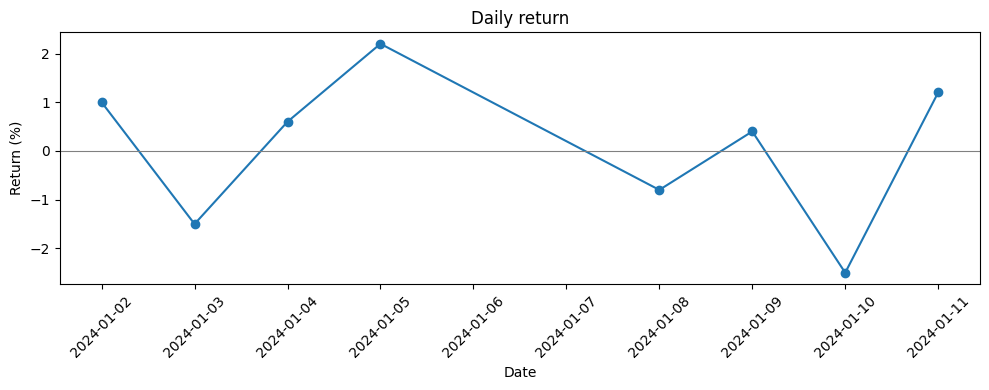

In [17]:
# 绘图代码：输入为上面格式的 df，可直接替换成你的表。
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")  # 折线必须按时间连接

plt.figure(figsize=(10, 4))
plt.plot(df["date"], df["ret"] * 100, marker="o")  # 小数转百分数
plt.axhline(0, color="grey", linewidth=0.8)
plt.title("Daily return")
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**图怎么读：** 1 月 5 日收益为 +2.2%，1 月 10 日为 -2.5%；水平线帮助区分上涨和下跌。

**换数据时注意：** 收益已有百分数数值（例如 1 表示 1%）时，不要再乘以 100。

<a id='V02'></a>
## V02 · 两只资产：从相同起点比较价格变化

**输入表：`df`（展示全部 8 行）**

| date | asset_a | asset_b |
| --- | --- | --- |
| 2024-01-02 | 100 | 50 |
| 2024-01-03 | 102 | 49 |
| 2024-01-04 | 101 | 51 |
| 2024-01-05 | 104 | 52 |
| 2024-01-08 | 103 | 53 |
| 2024-01-09 | 106 | 52 |
| 2024-01-10 | 108 | 54 |
| 2024-01-11 | 110 | 53 |

date 是共同交易日期；asset_a、asset_b 是两只资产的正价格；这个模板要求两列日期对齐且没有缺失值。

**要做什么：** 把两只资产第一天的价格都设为 100，放在同一张折线图里比较区间表现。

**代码：** 第一个代码格只生成上面的示例表；已有自己的同列名 `df` 时跳过它，直接复制第二个绘图格。

In [18]:
# 示例建表：已有自己的 df 时跳过这一格。
df = pd.DataFrame([
    ['2024-01-02', 100, 50],
    ['2024-01-03', 102, 49],
    ['2024-01-04', 101, 51],
    ['2024-01-05', 104, 52],
    ['2024-01-08', 103, 53],
    ['2024-01-09', 106, 52],
    ['2024-01-10', 108, 54],
    ['2024-01-11', 110, 53],
], columns=['date', 'asset_a', 'asset_b'])

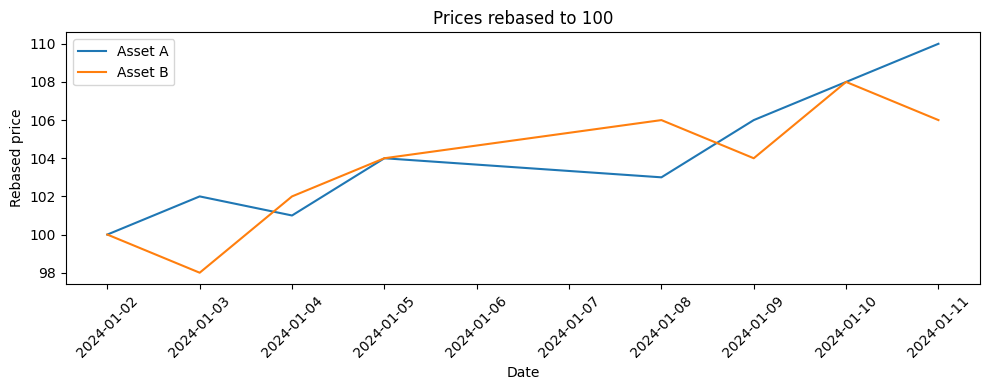

In [19]:
# 绘图代码：输入为上面格式的 df，可直接替换成你的表。
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
prices = df.set_index("date")[["asset_a", "asset_b"]]
rebased = prices / prices.iloc[0] * 100  # 用同一个起始日期

plt.figure(figsize=(10, 4))
plt.plot(rebased.index, rebased["asset_a"], label="Asset A")
plt.plot(rebased.index, rebased["asset_b"], label="Asset B")
plt.title("Prices rebased to 100")
plt.xlabel("Date")
plt.ylabel("Rebased price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**图怎么读：** 最后一天 A 为 110、B 为 106，表示相对共同起点，价格分别上涨 10% 和 6%。

**换数据时注意：** 比较投资表现时优先使用口径一致的复权价格；本例价格变化不包含手续费。

<a id='V03'></a>
## V03 · 缺失热图：看哪些日期、哪些列缺数据

**输入表：`df`（展示全部 8 行）**

| date | A | B | C |
| --- | --- | --- | --- |
| 2024-01-02 | 100 | 50 | 80 |
| 2024-01-03 | 101 | NaN | 81 |
| 2024-01-04 | 102 | NaN | 82 |
| 2024-01-05 | NaN | 52 | 83 |
| 2024-01-08 | 104 | 53 | NaN |
| 2024-01-09 | 105 | 54 | NaN |
| 2024-01-10 | 106 | 55 | NaN |
| 2024-01-11 | 107 | 56 | 87 |

date 按预期交易日每天一行；A、B、C 是待检查的数值列；空白表示缺失。整日缺数据也必须保留那一行。

**要做什么：** 用热图标出缺失位置：每一行是一个日期，每一列是一个字段，黄色代表缺失。

**代码：** 第一个代码格只生成上面的示例表；已有自己的同列名 `df` 时跳过它，直接复制第二个绘图格。

In [20]:
# 示例建表：已有自己的 df 时跳过这一格。
df = pd.DataFrame([
    ['2024-01-02', 100, 50, 80],
    ['2024-01-03', 101, None, 81],
    ['2024-01-04', 102, None, 82],
    ['2024-01-05', None, 52, 83],
    ['2024-01-08', 104, 53, None],
    ['2024-01-09', 105, 54, None],
    ['2024-01-10', 106, 55, None],
    ['2024-01-11', 107, 56, 87],
], columns=['date', 'A', 'B', 'C'])

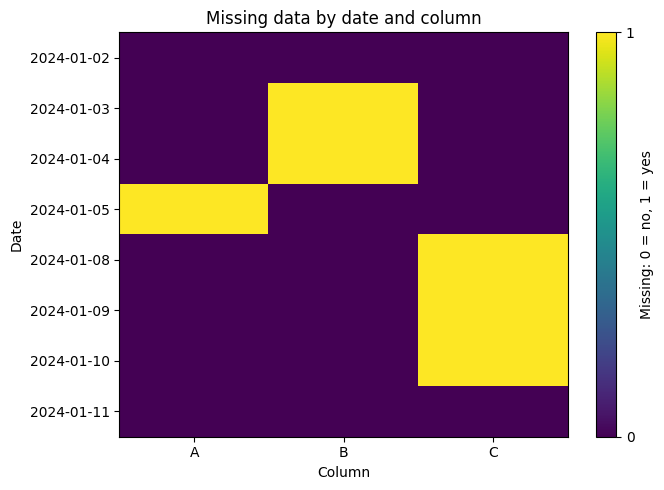

In [21]:
# 绘图代码：输入为上面格式的 df，可直接替换成你的表。
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
values = df.set_index("date")[["A", "B", "C"]]

plt.figure(figsize=(7, 5))
plt.imshow(values.isna(), aspect="auto", cmap="viridis", vmin=0, vmax=1)
plt.xticks(range(len(values.columns)), values.columns)
plt.yticks(range(len(values)), values.index.strftime("%Y-%m-%d"))
plt.colorbar(ticks=[0, 1], label="Missing: 0 = no, 1 = yes")
plt.title("Missing data by date and column")
plt.xlabel("Column")
plt.ylabel("Date")
plt.tight_layout()
plt.show()

**图怎么读：** B 在 1 月 3–4 日连续缺失，C 在 1 月 8–10 日连续缺失，A 只有 1 月 5 日缺失。

**换数据时注意：** 如果某个日期整行不存在，isna() 看不到它；先按正确的交易日历补齐日期。

<a id='V04'></a>
## V04 · 缺失率：快速比较哪些字段最不完整

**输入表：`df`（展示全部 8 行）**

| date | A | B | C |
| --- | --- | --- | --- |
| 2024-01-02 | 100 | 50 | 80 |
| 2024-01-03 | 101 | NaN | 81 |
| 2024-01-04 | 102 | NaN | 82 |
| 2024-01-05 | NaN | 52 | 83 |
| 2024-01-08 | 104 | 53 | NaN |
| 2024-01-09 | 105 | 54 | NaN |
| 2024-01-10 | 106 | 55 | NaN |
| 2024-01-11 | 107 | 56 | 87 |

每行对应一个预期交易日；A、B、C 是数值字段；缺失率的分母为这张表的全部行数。

**要做什么：** 计算 A、B、C 三列各自的缺失比例，按从高到低画柱状图。

**代码：** 第一个代码格只生成上面的示例表；已有自己的同列名 `df` 时跳过它，直接复制第二个绘图格。

In [22]:
# 示例建表：已有自己的 df 时跳过这一格。
df = pd.DataFrame([
    ['2024-01-02', 100, 50, 80],
    ['2024-01-03', 101, None, 81],
    ['2024-01-04', 102, None, 82],
    ['2024-01-05', None, 52, 83],
    ['2024-01-08', 104, 53, None],
    ['2024-01-09', 105, 54, None],
    ['2024-01-10', 106, 55, None],
    ['2024-01-11', 107, 56, 87],
], columns=['date', 'A', 'B', 'C'])

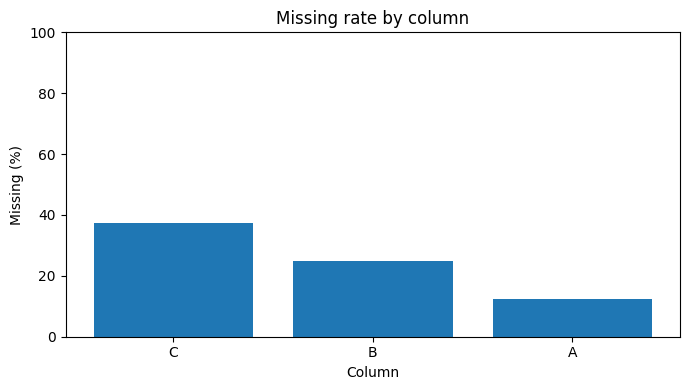

In [23]:
# 绘图代码：输入为上面格式的 df，可直接替换成你的表。
missing_pct = df[["A", "B", "C"]].isna().mean().sort_values(ascending=False) * 100

plt.figure(figsize=(7, 4))
plt.bar(missing_pct.index, missing_pct.values)
plt.title("Missing rate by column")
plt.xlabel("Column")
plt.ylabel("Missing (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

**图怎么读：** C 缺失 3/8 = 37.5%，B 缺失 25%，A 缺失 12.5%；可先检查 C 的来源与覆盖范围。

**换数据时注意：** 缺失率高不代表必须删列；先分清尚未上市、休市、无成交和采集失败。

<a id='V05'></a>
## V05 · 收益分布：看收益主要落在哪个范围

**输入表：`df`（展示全部 8 行）**

| ret |
| --- |
| -0.025 |
| -0.015 |
| -0.008 |
| 0.004 |
| 0.006 |
| 0.01 |
| 0.012 |
| 0.022 |

ret 是每个观测期的收益率，小数单位；所有行应采用相同的收益周期，例如全部为日收益。

**要做什么：** 把日收益画成直方图，横轴用百分数，纵轴表示落入该区间的观测数量。

**代码：** 第一个代码格只生成上面的示例表；已有自己的同列名 `df` 时跳过它，直接复制第二个绘图格。

In [24]:
# 示例建表：已有自己的 df 时跳过这一格。
df = pd.DataFrame([
    [-0.025],
    [-0.015],
    [-0.008],
    [0.004],
    [0.006],
    [0.01],
    [0.012],
    [0.022],
], columns=['ret'])

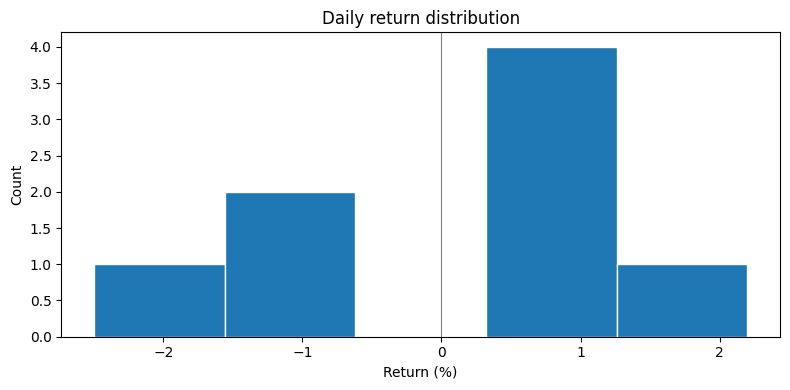

In [25]:
# 绘图代码：输入为上面格式的 df，可直接替换成你的表。
returns_pct = df["ret"].dropna() * 100  # 绘图时忽略缺失，不把它当作 0

plt.figure(figsize=(8, 4))
plt.hist(returns_pct, bins=5, edgecolor="white")
plt.axvline(0, color="grey", linewidth=0.8)
plt.title("Daily return distribution")
plt.xlabel("Return (%)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**图怎么读：** 柱子的高度表示样本在各收益区间的数量；这个小例子同时包含正收益和负收益。

**换数据时注意：** 8 行只用于演示语法；真实分布分析需要更多样本，分箱数量也会影响外观。

<a id='V06'></a>
## V06 · 大幅波动：标出绝对收益超过 2% 的日期

**输入表：`df`（展示全部 8 行）**

| date | ret |
| --- | --- |
| 2024-01-02 | 0.01 |
| 2024-01-03 | -0.015 |
| 2024-01-04 | 0.006 |
| 2024-01-05 | 0.022 |
| 2024-01-08 | -0.008 |
| 2024-01-09 | 0.004 |
| 2024-01-10 | -0.025 |
| 2024-01-11 | 0.012 |

date 是日期，ret 是小数单位的日收益；阈值 0.02 表示 2%。

**要做什么：** 画日收益折线，并用红点突出绝对收益大于 2% 的观测，方便回查原始数据。

**代码：** 第一个代码格只生成上面的示例表；已有自己的同列名 `df` 时跳过它，直接复制第二个绘图格。

In [26]:
# 示例建表：已有自己的 df 时跳过这一格。
df = pd.DataFrame([
    ['2024-01-02', 0.01],
    ['2024-01-03', -0.015],
    ['2024-01-04', 0.006],
    ['2024-01-05', 0.022],
    ['2024-01-08', -0.008],
    ['2024-01-09', 0.004],
    ['2024-01-10', -0.025],
    ['2024-01-11', 0.012],
], columns=['date', 'ret'])

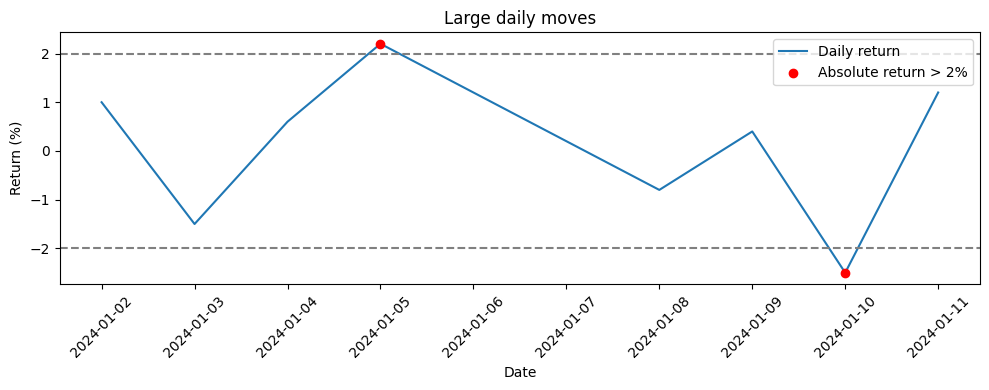

In [27]:
# 绘图代码：输入为上面格式的 df，可直接替换成你的表。
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
large_move = df["ret"].abs() > 0.02  # 固定阈值，可按任务调整

plt.figure(figsize=(10, 4))
plt.plot(df["date"], df["ret"] * 100, label="Daily return")
plt.scatter(df.loc[large_move, "date"], df.loc[large_move, "ret"] * 100, color="red", label="Absolute return > 2%", zorder=3)
plt.axhline(2, color="grey", linestyle="--")
plt.axhline(-2, color="grey", linestyle="--")
plt.title("Large daily moves")
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**图怎么读：** 红点对应 1 月 5 日的 +2.2% 和 1 月 10 日的 -2.5%，是优先回查的日期。

**换数据时注意：** 大幅波动可能是真实行情，不能仅凭超过阈值就认定错误或删除。

<a id='V07'></a>
## V07 · 滚动波动：看近期收益是否越来越不稳定

**输入表：`df`（展示全部 8 行）**

| date | ret |
| --- | --- |
| 2024-01-02 | 0.002 |
| 2024-01-03 | -0.003 |
| 2024-01-04 | 0.004 |
| 2024-01-05 | -0.002 |
| 2024-01-08 | 0.02 |
| 2024-01-09 | -0.025 |
| 2024-01-10 | 0.03 |
| 2024-01-11 | -0.018 |

date 是交易日期；ret 是小数单位的日收益；每个交易日只有一行。

**要做什么：** 计算过去 3 个观测的日收益样本标准差，画折线观察波动水平的变化，不做年化。

**代码：** 第一个代码格只生成上面的示例表；已有自己的同列名 `df` 时跳过它，直接复制第二个绘图格。

In [28]:
# 示例建表：已有自己的 df 时跳过这一格。
df = pd.DataFrame([
    ['2024-01-02', 0.002],
    ['2024-01-03', -0.003],
    ['2024-01-04', 0.004],
    ['2024-01-05', -0.002],
    ['2024-01-08', 0.02],
    ['2024-01-09', -0.025],
    ['2024-01-10', 0.03],
    ['2024-01-11', -0.018],
], columns=['date', 'ret'])

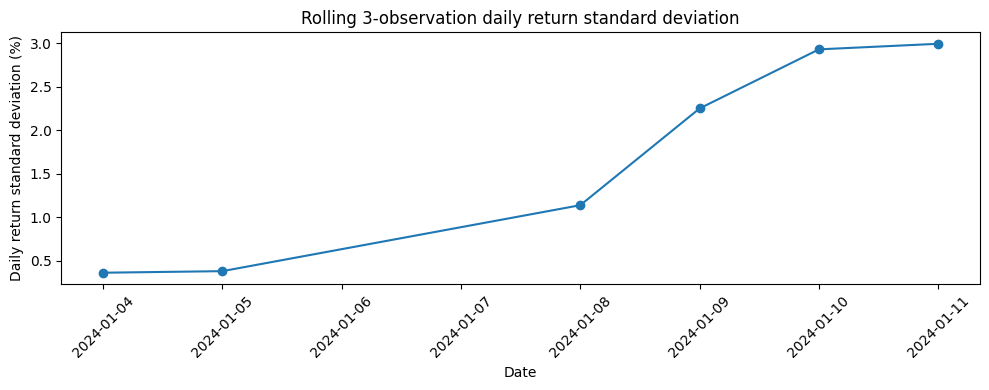

In [29]:
# 绘图代码：输入为上面格式的 df，可直接替换成你的表。
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
rolling_std = df["ret"].rolling(3, min_periods=3).std()  # 包含当前行，默认 ddof=1

plt.figure(figsize=(10, 4))
plt.plot(df["date"], rolling_std * 100, marker="o")
plt.title("Rolling 3-observation daily return standard deviation")
plt.xlabel("Date")
plt.ylabel("Daily return standard deviation (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**图怎么读：** 前两行因观测不足没有结果；后半段收益振幅增大，滚动标准差明显上升。

**换数据时注意：** 窗口 3 仅供小表演示，实际常改为 20 或 60；它数的是观测行，不是日历天。

<a id='V08'></a>
## V08 · 滚动相关：看两只资产的联动是否变化

**输入表：`df`（展示全部 8 行）**

| date | ret_a | ret_b |
| --- | --- | --- |
| 2024-01-02 | 0.01 | 0.008 |
| 2024-01-03 | -0.01 | -0.009 |
| 2024-01-04 | 0.02 | 0.017 |
| 2024-01-05 | -0.02 | -0.016 |
| 2024-01-08 | 0.015 | -0.014 |
| 2024-01-09 | -0.015 | 0.016 |
| 2024-01-10 | 0.025 | -0.02 |
| 2024-01-11 | -0.025 | 0.022 |

date 是双方共同交易日期；ret_a、ret_b 是同期日收益率，小数单位，按日期一一对应。

**要做什么：** 计算两只资产最近 3 个观测的相关系数，画出联动从同向到反向的变化。

**代码：** 第一个代码格只生成上面的示例表；已有自己的同列名 `df` 时跳过它，直接复制第二个绘图格。

In [30]:
# 示例建表：已有自己的 df 时跳过这一格。
df = pd.DataFrame([
    ['2024-01-02', 0.01, 0.008],
    ['2024-01-03', -0.01, -0.009],
    ['2024-01-04', 0.02, 0.017],
    ['2024-01-05', -0.02, -0.016],
    ['2024-01-08', 0.015, -0.014],
    ['2024-01-09', -0.015, 0.016],
    ['2024-01-10', 0.025, -0.02],
    ['2024-01-11', -0.025, 0.022],
], columns=['date', 'ret_a', 'ret_b'])

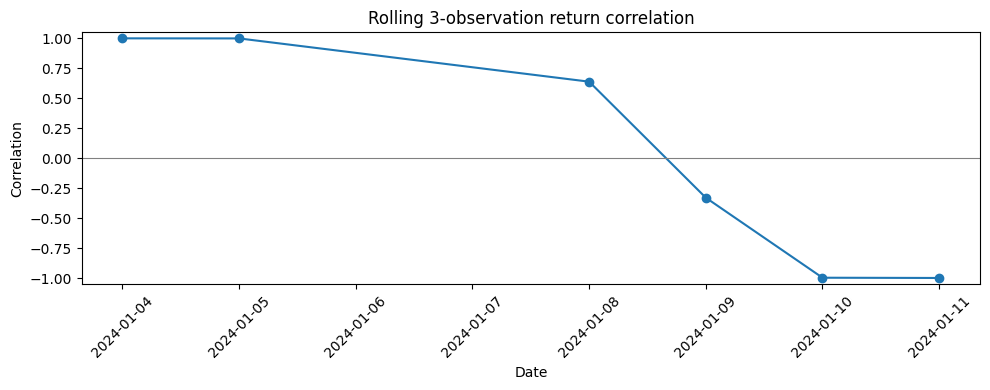

In [31]:
# 绘图代码：输入为上面格式的 df，可直接替换成你的表。
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
rolling_corr = df["ret_a"].rolling(3, min_periods=3).corr(df["ret_b"])

plt.figure(figsize=(10, 4))
plt.plot(df["date"], rolling_corr, marker="o")
plt.axhline(0, color="grey", linewidth=0.8)
plt.ylim(-1.05, 1.05)
plt.title("Rolling 3-observation return correlation")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**图怎么读：** 前半段相关系数接近 +1，后半段接近 -1；这组演示数据刻意展示联动方向变化。

**换数据时注意：** 3 对观测的相关性非常不稳定；实际应扩大窗口，窗口内不足 3 对或某列恒定时结果为缺失。

<a id='V09'></a>
## V09 · 相关矩阵：比较多只资产的同期收益关系

**输入表：`df`（展示全部 8 行）**

| A | B | C |
| --- | --- | --- |
| 0.01 | 0.008 | -0.009 |
| -0.01 | -0.007 | 0.008 |
| 0.02 | 0.016 | -0.012 |
| -0.02 | -0.015 | 0.019 |
| 0.015 | NaN | -0.01 |
| -0.015 | -0.009 | NaN |
| 0.025 | 0.019 | -0.021 |
| -0.025 | -0.018 | 0.024 |

每一行代表同一个交易日，A、B、C 是三只资产的小数日收益；列间已按日期对齐，空白为缺失。

**要做什么：** 先列出每两列共同非空的样本数，再画收益相关系数热图，比较正相关与负相关。

**代码：** 第一个代码格只生成上面的示例表；已有自己的同列名 `df` 时跳过它，直接复制第二个绘图格。

In [32]:
# 示例建表：已有自己的 df 时跳过这一格。
df = pd.DataFrame([
    [0.01, 0.008, -0.009],
    [-0.01, -0.007, 0.008],
    [0.02, 0.016, -0.012],
    [-0.02, -0.015, 0.019],
    [0.015, None, -0.01],
    [-0.015, -0.009, None],
    [0.025, 0.019, -0.021],
    [-0.025, -0.018, 0.024],
], columns=['A', 'B', 'C'])

,A,B,C
A,8,7,7
B,7,7,6
C,7,6,7


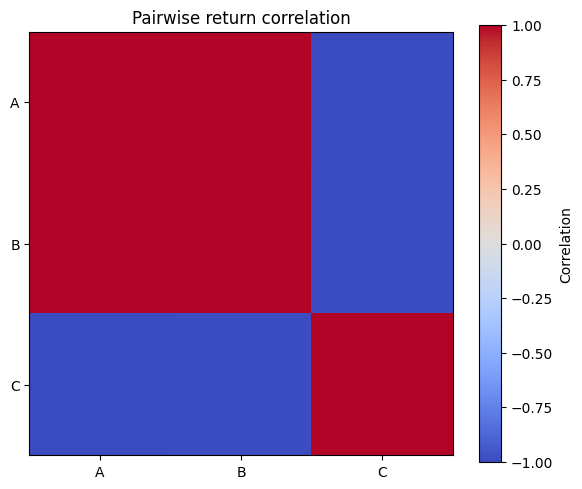

In [33]:
# 绘图代码：输入为上面格式的 df，可直接替换成你的表。
returns = df[["A", "B", "C"]]
valid = returns.notna().astype(int)
pair_counts = valid.T.dot(valid)  # 每对资产共同非空的观测数
display(pair_counts)
corr = returns.corr(min_periods=3)

plt.figure(figsize=(6, 5))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr)), corr.columns)
plt.yticks(range(len(corr)), corr.index)
plt.colorbar(label="Correlation")
plt.title("Pairwise return correlation")
plt.tight_layout()
plt.show()

**图怎么读：** A 与 B 正相关，C 与它们负相关；A–B 和 A–C 各有 7 对观测，B–C 只有 6 对。

**换数据时注意：** 相关性不表示因果；缺失模式不同会让各格子使用不同日期，必须一起检查样本数。

<a id='V10'></a>
## V10 · 今日收益与下一交易日收益散点图

**输入表：`df`（展示全部 8 行）**

| date | ret |
| --- | --- |
| 2024-01-02 | 0.012 |
| 2024-01-03 | -0.008 |
| 2024-01-04 | 0.006 |
| 2024-01-05 | -0.015 |
| 2024-01-08 | 0.004 |
| 2024-01-09 | 0.011 |
| 2024-01-10 | -0.003 |
| 2024-01-11 | 0.007 |

date 是同一资产不重复、无缺交易日的日期；ret 是日收益的小数，例如 0.012 表示 1.2%。

**要做什么：** 把今日收益放在横轴，下一交易日收益放在纵轴，观察两者是否存在明显关系。

**代码：** 第一个代码格只生成上面的示例表；已有自己的同列名 `df` 时跳过它，直接复制第二个绘图格。

In [34]:
# 示例建表：已有自己的 df 时跳过这一格。
df = pd.DataFrame([
    ['2024-01-02', 0.012],
    ['2024-01-03', -0.008],
    ['2024-01-04', 0.006],
    ['2024-01-05', -0.015],
    ['2024-01-08', 0.004],
    ['2024-01-09', 0.011],
    ['2024-01-10', -0.003],
    ['2024-01-11', 0.007],
], columns=['date', 'ret'])

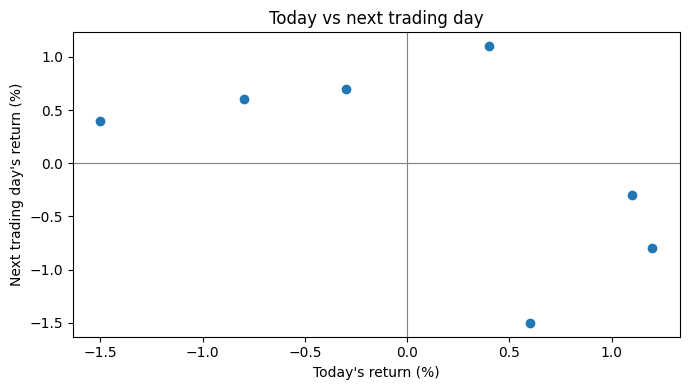

In [35]:
# 绘图代码：输入为上面格式的 df，可直接替换成你的表。
# 先按日期排序，再把下一行收益移到今天这一行。
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").copy()
df["next_ret"] = df["ret"].shift(-1)
pairs = df[["ret", "next_ret"]].dropna()  # 两列必须成对删除缺失值

plt.figure(figsize=(7, 4))
plt.scatter(pairs["ret"] * 100, pairs["next_ret"] * 100)
plt.axhline(0, color="grey", linewidth=0.8)
plt.axvline(0, color="grey", linewidth=0.8)
plt.title("Today vs next trading day")
plt.xlabel("Today's return (%)")
plt.ylabel("Next trading day's return (%)")
plt.tight_layout()
plt.show()

**图怎么读：** 每个点是一对相邻交易日的收益；点云形状可以提示后续要检验的关系。

**换数据时注意：** 这里只有 7 对观测，不能据此判断预测能力；若日期有缺口，下一行不一定是下一交易日。

<a id='V11'></a>
## V11 · 收益自相关柱状图

**输入表：`df`（展示全部 10 行）**

| date | ret |
| --- | --- |
| 2024-01-02 | 0.012 |
| 2024-01-03 | -0.008 |
| 2024-01-04 | 0.006 |
| 2024-01-05 | -0.015 |
| 2024-01-08 | 0.004 |
| 2024-01-09 | 0.011 |
| 2024-01-10 | -0.003 |
| 2024-01-11 | 0.007 |
| 2024-01-12 | -0.006 |
| 2024-01-15 | 0.002 |

date 是同一资产完整的交易日序列；ret 是收益小数，此例以交易日观测数作为滞后单位。

**要做什么：** 计算收益与前 1、2、3 个交易日收益的相关系数，并画成柱状图。

**代码：** 第一个代码格只生成上面的示例表；已有自己的同列名 `df` 时跳过它，直接复制第二个绘图格。

In [36]:
# 示例建表：已有自己的 df 时跳过这一格。
df = pd.DataFrame([
    ['2024-01-02', 0.012],
    ['2024-01-03', -0.008],
    ['2024-01-04', 0.006],
    ['2024-01-05', -0.015],
    ['2024-01-08', 0.004],
    ['2024-01-09', 0.011],
    ['2024-01-10', -0.003],
    ['2024-01-11', 0.007],
    ['2024-01-12', -0.006],
    ['2024-01-15', 0.002],
], columns=['date', 'ret'])

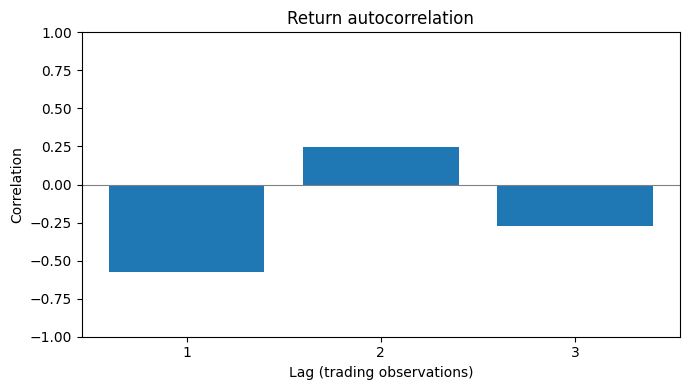

In [37]:
# 绘图代码：输入为上面格式的 df，可直接替换成你的表。
df["date"] = pd.to_datetime(df["date"])
ret = df.sort_values("date")["ret"]
lags = [1, 2, 3]
correlations = [ret.autocorr(lag=k) for k in lags]

plt.figure(figsize=(7, 4))
plt.bar(lags, correlations)
plt.axhline(0, color="grey", linewidth=0.8)
plt.xticks(lags)
plt.ylim(-1, 1)
plt.title("Return autocorrelation")
plt.xlabel("Lag (trading observations)")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()

**图怎么读：** 每根柱子显示一个滞后的相关系数，正负号分别表示同向和反向关系。

**换数据时注意：** 10 条数据仅用于演示代码，没有置信区间；柱子较高也不能说明存在稳定规律。

<a id='V12'></a>
## V12 · 不同星期的收益箱线图

**输入表：`df`（展示全部 10 行）**

| date | ret |
| --- | --- |
| 2024-01-08 | 0.012 |
| 2024-01-09 | -0.006 |
| 2024-01-10 | 0.003 |
| 2024-01-11 | -0.009 |
| 2024-01-12 | 0.007 |
| 2024-01-15 | -0.005 |
| 2024-01-16 | 0.004 |
| 2024-01-17 | -0.002 |
| 2024-01-18 | 0.006 |
| 2024-01-19 | 0.001 |

date 是日收益所属的交易日期，ret 是收益小数；本例每个星期类别恰有两条记录。

**要做什么：** 按星期一到星期五分组，用箱线图比较各组收益的分布。

**代码：** 第一个代码格只生成上面的示例表；已有自己的同列名 `df` 时跳过它，直接复制第二个绘图格。

In [38]:
# 示例建表：已有自己的 df 时跳过这一格。
df = pd.DataFrame([
    ['2024-01-08', 0.012],
    ['2024-01-09', -0.006],
    ['2024-01-10', 0.003],
    ['2024-01-11', -0.009],
    ['2024-01-12', 0.007],
    ['2024-01-15', -0.005],
    ['2024-01-16', 0.004],
    ['2024-01-17', -0.002],
    ['2024-01-18', 0.006],
    ['2024-01-19', 0.001],
], columns=['date', 'ret'])

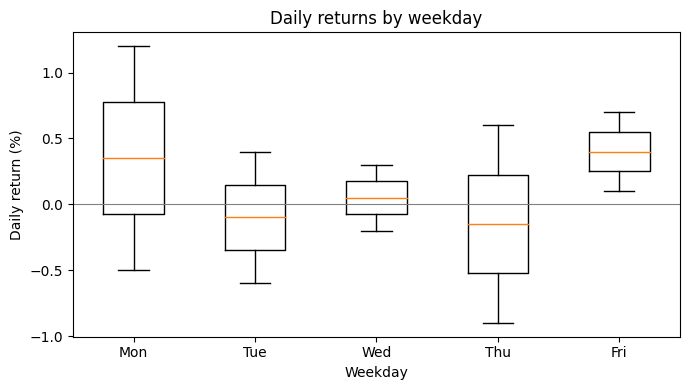

In [39]:
# 绘图代码：输入为上面格式的 df，可直接替换成你的表。
weekday = pd.to_datetime(df["date"]).dt.dayofweek  # 周一=0，周五=4
groups = [df.loc[weekday == k, "ret"].dropna() * 100 for k in range(5)]

plt.figure(figsize=(7, 4))
plt.boxplot(groups)
plt.xticks([1, 2, 3, 4, 5], ["Mon", "Tue", "Wed", "Thu", "Fri"])
plt.axhline(0, color="grey", linewidth=0.8)
plt.title("Daily returns by weekday")
plt.xlabel("Weekday")
plt.ylabel("Daily return (%)")
plt.tight_layout()
plt.show()

**图怎么读：** 箱体和中位线用于比较各组分布；本例每组只有两个点，形状只是绘图示意。

**换数据时注意：** 真实分析需要更多样本和分期检验；不要从这 10 条数据推断星期效应。

<a id='V13'></a>
## V13 · 月度收益热力图

**输入表：`df`（展示全部 8 行）**

| month | monthly_ret |
| --- | --- |
| 2023-01-01 | 0.025 |
| 2023-02-01 | -0.018 |
| 2023-03-01 | 0.01 |
| 2023-04-01 | 0.036 |
| 2024-03-01 | -0.028 |
| 2024-04-01 | 0.014 |
| 2024-05-01 | -0.007 |
| 2024-06-01 | 0.022 |

每行已是一个完整月份的复合收益，monthly_ret 为小数；每月只有一行，未提供的月份保留缺失。

**要做什么：** 把年份放在行、月份放在列，用颜色展示每个月的收益。

**代码：** 第一个代码格只生成上面的示例表；已有自己的同列名 `df` 时跳过它，直接复制第二个绘图格。

In [40]:
# 示例建表：已有自己的 df 时跳过这一格。
df = pd.DataFrame([
    ['2023-01-01', 0.025],
    ['2023-02-01', -0.018],
    ['2023-03-01', 0.01],
    ['2023-04-01', 0.036],
    ['2024-03-01', -0.028],
    ['2024-04-01', 0.014],
    ['2024-05-01', -0.007],
    ['2024-06-01', 0.022],
], columns=['month', 'monthly_ret'])

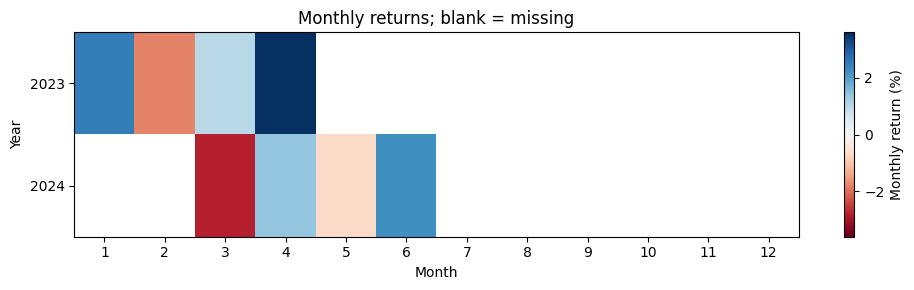

In [41]:
# 绘图代码：输入为上面格式的 df，可直接替换成你的表。
month = pd.to_datetime(df["month"])
table = df.assign(year=month.dt.year, month_number=month.dt.month).pivot(
    index="year", columns="month_number", values="monthly_ret")
table = table.reindex(columns=range(1, 13))  # 缺月保持 NaN，不填零
limit = table.abs().max().max() * 100

plt.figure(figsize=(10, 3))
plt.imshow(table * 100, aspect="auto", cmap="RdBu", vmin=-limit, vmax=limit)
plt.colorbar(label="Monthly return (%)")
plt.xticks(range(12), range(1, 13))
plt.yticks(range(len(table)), table.index)
plt.title("Monthly returns; blank = missing")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

**图怎么读：** 颜色深浅表示收益幅度；空白格表示没有该月数据，不表示收益为零。

**换数据时注意：** 先确认日数据覆盖完整月份再计算月收益；此模板只负责绘制已经验证的月收益。

<a id='V14'></a>
## V14 · 每日成交量柱状图

**输入表：`df`（展示全部 8 行）**

| date | volume |
| --- | --- |
| 2024-01-02 | 1250000 |
| 2024-01-03 | 1180000 |
| 2024-01-04 | 1420000 |
| 2024-01-05 | 3200000 |
| 2024-01-08 | 1670000 |
| 2024-01-09 | 1360000 |
| 2024-01-10 | 1210000 |
| 2024-01-11 | 1490000 |

date 是同一资产的日期，volume 是当日成交股数；如果原数据是手数或成交额，需要相应修改纵轴单位。

**要做什么：** 画每日成交量，找出明显放量的日期。

**代码：** 第一个代码格只生成上面的示例表；已有自己的同列名 `df` 时跳过它，直接复制第二个绘图格。

In [42]:
# 示例建表：已有自己的 df 时跳过这一格。
df = pd.DataFrame([
    ['2024-01-02', 1250000],
    ['2024-01-03', 1180000],
    ['2024-01-04', 1420000],
    ['2024-01-05', 3200000],
    ['2024-01-08', 1670000],
    ['2024-01-09', 1360000],
    ['2024-01-10', 1210000],
    ['2024-01-11', 1490000],
], columns=['date', 'volume'])

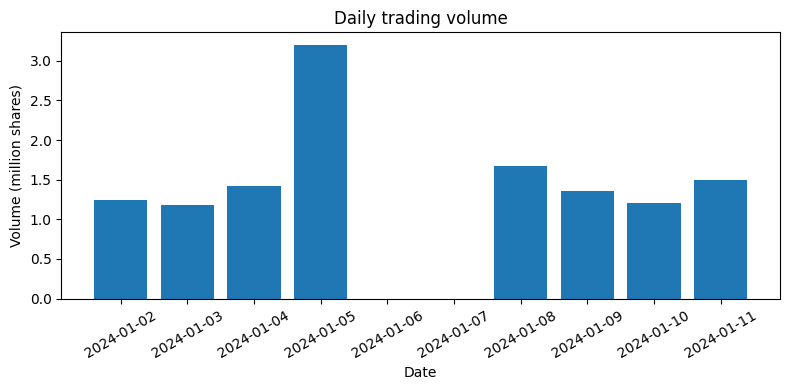

In [43]:
# 绘图代码：输入为上面格式的 df，可直接替换成你的表。
dates = pd.to_datetime(df["date"])

plt.figure(figsize=(8, 4))
plt.bar(dates, df["volume"] / 1000000)
plt.title("Daily trading volume")
plt.xlabel("Date")
plt.ylabel("Volume (million shares)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**图怎么读：** 示例中 1 月 5 日的柱子明显更高，可以回到原始记录检查当天发生了什么。

**换数据时注意：** 周末留白属于日期轴的正常间隔；成交量增加本身不说明未来价格会上涨。

<a id='V15'></a>
## V15 · 在时间序列上标出训练与测试边界

**输入表：`df`（展示全部 8 行）**

| date | value |
| --- | --- |
| 2024-01-02 | 100 |
| 2024-01-03 | 102 |
| 2024-01-04 | 101 |
| 2024-01-05 | 104 |
| 2024-01-08 | 103 |
| 2024-01-09 | 106 |
| 2024-01-10 | 105 |
| 2024-01-11 | 108 |

date 是观测日期，value 是要检查的数值；本例约定 2024-01-08 起的数据属于测试区间。

**要做什么：** 画出时间序列，并在测试集开始的日期画一条竖线。

**代码：** 第一个代码格只生成上面的示例表；已有自己的同列名 `df` 时跳过它，直接复制第二个绘图格。

In [44]:
# 示例建表：已有自己的 df 时跳过这一格。
df = pd.DataFrame([
    ['2024-01-02', 100],
    ['2024-01-03', 102],
    ['2024-01-04', 101],
    ['2024-01-05', 104],
    ['2024-01-08', 103],
    ['2024-01-09', 106],
    ['2024-01-10', 105],
    ['2024-01-11', 108],
], columns=['date', 'value'])

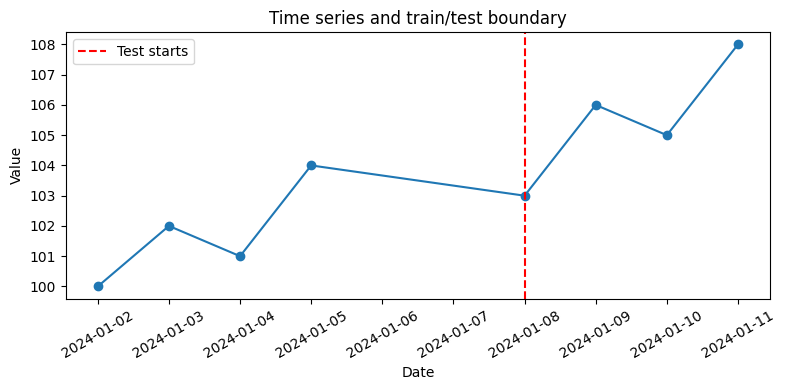

In [45]:
# 绘图代码：输入为上面格式的 df，可直接替换成你的表。
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
test_start = pd.Timestamp("2024-01-08")  # 替换成你预先确定的测试起点

plt.figure(figsize=(8, 4))
plt.plot(pd.to_datetime(df["date"]), df["value"], marker="o")
plt.axvline(test_start, color="red", linestyle="--", label="Test starts")
plt.title("Time series and train/test boundary")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**图怎么读：** 红线之前为训练区间，红线当天及之后为测试区间，便于检查两段数据覆盖范围。

**换数据时注意：** 画边界不等于已消除泄漏；预处理参数仍须只从训练集估计，跨边界的预测标签也须处理。

<a id='V16'></a>
## V16 · 不同特征分组的下一期平均收益

**输入表：`df`（展示全部 9 行）**

| bucket | next_ret |
| --- | --- |
| Low | -0.01 |
| Low | 0.004 |
| Low | -0.003 |
| Mid | 0.002 |
| Mid | -0.004 |
| Mid | 0.005 |
| High | 0.008 |
| High | -0.002 |
| High | 0.006 |

bucket 是使用当时可知特征和事先固定规则得到的组别；next_ret 为下一期收益小数，仅用于事后评估。

**要做什么：** 比较 Low、Mid、High 三组的下一期平均收益，同时列出每组有效样本数。

**代码：** 第一个代码格只生成上面的示例表；已有自己的同列名 `df` 时跳过它，直接复制第二个绘图格。

In [46]:
# 示例建表：已有自己的 df 时跳过这一格。
df = pd.DataFrame([
    ['Low', -0.01],
    ['Low', 0.004],
    ['Low', -0.003],
    ['Mid', 0.002],
    ['Mid', -0.004],
    ['Mid', 0.005],
    ['High', 0.008],
    ['High', -0.002],
    ['High', 0.006],
], columns=['bucket', 'next_ret'])

,平均收益（小数）,有效样本数
bucket,,
Low,-0.003,3
Mid,0.001,3
High,0.004,3


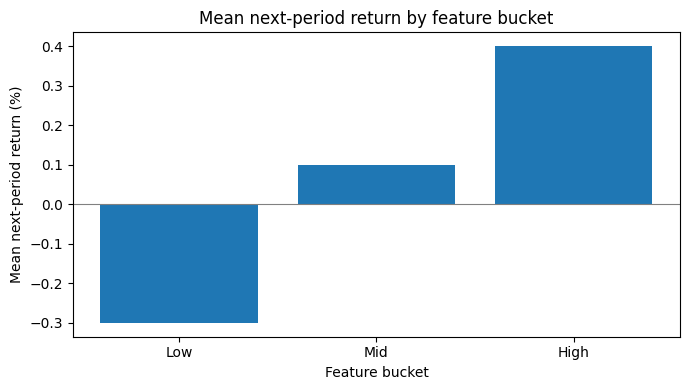

In [47]:
# 绘图代码：输入为上面格式的 df，可直接替换成你的表。
summary = df.groupby("bucket")["next_ret"].agg(["mean", "count"])
summary = summary.reindex(["Low", "Mid", "High"])
display(summary.rename(columns={"mean": "平均收益（小数）", "count": "有效样本数"}))

plt.figure(figsize=(7, 4))
plt.bar(summary.index, summary["mean"] * 100)
plt.axhline(0, color="grey", linewidth=0.8)
plt.title("Mean next-period return by feature bucket")
plt.xlabel("Feature bucket")
plt.ylabel("Mean next-period return (%)")
plt.tight_layout()
plt.show()

**图怎么读：** 柱子比较各组的下一期平均收益；同时看表中样本数，避免把少量观测的均值当作稳定效果。

**换数据时注意：** 分组规则不能根据这些未来收益反向选择；图中关系尚未检验显著性、交易成本或样本外表现。

<a id='V17'></a>
## V17 · 从日收益计算并画回撤

**输入表：`df`（展示全部 8 行）**

| date | ret |
| --- | --- |
| 2024-01-02 | -0.02 |
| 2024-01-03 | 0.01 |
| 2024-01-04 | 0.03 |
| 2024-01-05 | -0.04 |
| 2024-01-08 | -0.015 |
| 2024-01-09 | 0.02 |
| 2024-01-10 | 0.01 |
| 2024-01-11 | 0.035 |

date 是唯一且完整的日期序列；ret 是不含缺失、均大于 -1 的日收益小数，初始净值设为 1。

**要做什么：** 把日收益复合成净值，计算相对历史最高净值的跌幅，并画回撤曲线。

**代码：** 第一个代码格只生成上面的示例表；已有自己的同列名 `df` 时跳过它，直接复制第二个绘图格。

In [48]:
# 示例建表：已有自己的 df 时跳过这一格。
df = pd.DataFrame([
    ['2024-01-02', -0.02],
    ['2024-01-03', 0.01],
    ['2024-01-04', 0.03],
    ['2024-01-05', -0.04],
    ['2024-01-08', -0.015],
    ['2024-01-09', 0.02],
    ['2024-01-10', 0.01],
    ['2024-01-11', 0.035],
], columns=['date', 'ret'])

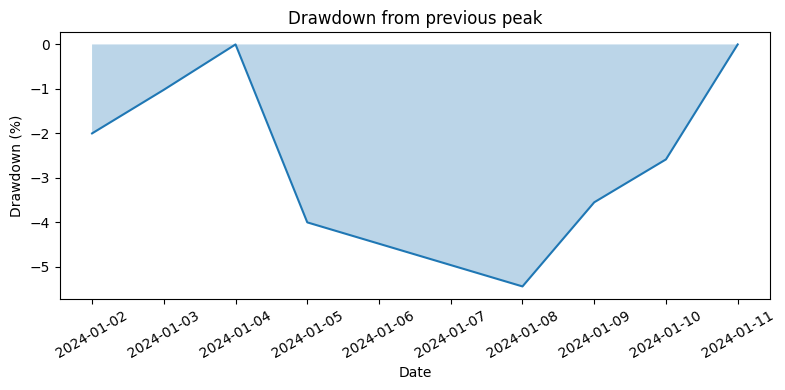

In [49]:
# 绘图代码：输入为上面格式的 df，可直接替换成你的表。
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
wealth = (1 + df["ret"]).cumprod()  # 初始净值为 1
peak = wealth.cummax().clip(lower=1)  # 把初始净值纳入历史最高值
drawdown = wealth / peak - 1
dates = pd.to_datetime(df["date"])

plt.figure(figsize=(8, 4))
plt.fill_between(dates, drawdown * 100, 0, alpha=0.3)
plt.plot(dates, drawdown * 100)
plt.title("Drawdown from previous peak")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**图怎么读：** 曲线越低，距离此前最高净值越远；本例第一天亏损也会正确显示为负回撤。

**换数据时注意：** 缺失收益不能默认填零；若输入为策略收益，还须明确是否已扣除交易成本。

<a id='V18'></a>
## V18 · 每小时事件数量柱状图

**输入表：`df`（展示全部 8 行）**

| timestamp |
| --- |
| 2024-01-08 09:10:00 |
| 2024-01-08 09:42:00 |
| 2024-01-08 10:15:00 |
| 2024-01-08 12:05:00 |
| 2024-01-08 12:20:00 |
| 2024-01-08 12:51:00 |
| 2024-01-08 13:08:00 |
| 2024-01-08 14:25:00 |

每行是一条事件；timestamp 使用同一时区，本例确认当天 09:00 至 15:00 的采集持续完整。

**要做什么：** 按小时统计事件条数，并显示完全没有事件的小时。

**代码：** 第一个代码格只生成上面的示例表；已有自己的同列名 `df` 时跳过它，直接复制第二个绘图格。

In [50]:
# 示例建表：已有自己的 df 时跳过这一格。
df = pd.DataFrame([
    ['2024-01-08 09:10:00'],
    ['2024-01-08 09:42:00'],
    ['2024-01-08 10:15:00'],
    ['2024-01-08 12:05:00'],
    ['2024-01-08 12:20:00'],
    ['2024-01-08 12:51:00'],
    ['2024-01-08 13:08:00'],
    ['2024-01-08 14:25:00'],
], columns=['timestamp'])

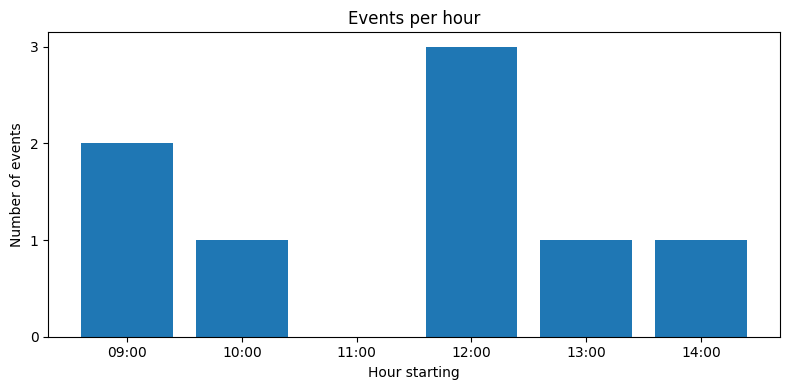

In [51]:
# 绘图代码：输入为上面格式的 df，可直接替换成你的表。
events = df.assign(timestamp=pd.to_datetime(df["timestamp"]))
counts = events.set_index("timestamp").resample("1h").size()
# 替换成实际已确认完整采集的起止小时；本例最后一格覆盖 14:00–15:00。
hours = pd.date_range("2024-01-08 09:00", "2024-01-08 14:00", freq="1h")
counts = counts.reindex(hours, fill_value=0)  # 使用已确认完整的采集区间

plt.figure(figsize=(8, 4))
plt.bar(counts.index.strftime("%H:%M"), counts.values)
plt.title("Events per hour")
plt.xlabel("Hour starting")
plt.ylabel("Number of events")
plt.yticks(range(int(counts.max()) + 1))
plt.tight_layout()
plt.show()

**图怎么读：** 12 点这一小时有三条事件，11 点这一小时为零，方便观察事件到达是否均匀。

**换数据时注意：** 只有确认采集完整时，空小时才可记为零；采集故障导致的缺失必须另行标记。

### 怎么套到自己的数据

只需要把表名、列名和单位对应上。例如 V01 需要 `date` 和 `ret`：

```python
df = my_data.rename(columns={"timestamp": "date", "return": "ret"}).copy()
# 确认 ret 是小数收益，再复制 V01 的绘图格。
```

一次选择一个案例；不需要把 18 个案例连成一条流程。V03 的日期应先按预期日历补齐，V13 的输入已经是完整月收益，V16 的分组规则已经事先固定。相关的数据处理可查前面的 D 模板。

### 官方参考

- [pandas 1.5 时间序列](https://pandas.pydata.org/pandas-docs/version/1.5/user_guide/timeseries.html)
- [pandas 1.5 窗口计算](https://pandas.pydata.org/pandas-docs/version/1.5/user_guide/window.html)
- [Matplotlib 3.7 pyplot 教程](https://matplotlib.org/3.7.5/tutorials/introductory/pyplot.html)

图形用于描述数据和提出问题；不能仅凭示例图推断因果、稳定预测能力或可盈利策略。建模与回测预留在第三本 notebook。